# EDA Finale — Reddit Engagement Optimizer
### À lancer sur n'importe quel subreddit — changer uniquement le nom du fichier CSV en cellule 1

In [ ]:
"""Cellule 1 - Configuration.

Définit les paramètres globaux du notebook : nom du fichier CSV source,
nom du fichier de sortie enrichi et nom du subreddit analysé.
Cette cellule est la seule à modifier pour adapter le notebook à un nouveau subreddit.
"""


# CELLULE 1 — CONFIGURATION (seule cellule à modifier)
NOM_FICHIER  = "nom du fichier csv"       # <- changer ici selon le subreddit
NOM_SORTIE   = "nom du fichier csv_enrichie"  # <- nom du fichier enrichi en sortie
NOM_SUBREDDIT = "nom du subreddit"          # <- nom affiché dans les graphiques

In [ ]:
"""Cellule 2 - Imports et chargement des données.

Importe les bibliothèques nécessaires à l'analyse (pandas, matplotlib, seaborn,
numpy, re, nltk) et charge le fichier CSV spécifié en cellule 1.
Affiche le subreddit, le nombre de posts chargés et la liste des colonnes.
"""


# CELLULE 2 — IMPORTS ET CHARGEMENT
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

df = pd.read_csv(NOM_FICHIER)

print(f'Subreddit : r/{NOM_SUBREDDIT}')
print(f'Posts chargés : {len(df)}')
print(f'Colonnes : {list(df.columns)}')

Subreddit : r/histoire
Posts chargés : 2137
Colonnes : ['id', 'titre', 'score', 'upvote_ratio', 'nb_commentaires', 'created_utc', 'flair', 'est_texte', 'contenu', 'url', 'subreddit']


In [ ]:
"""Cellule 3 - Création de toutes les features.

Calcul et ajout de nouvelles colonnes au dataframe :
- Features temporelles : heure, jour de la semaine, mois, tranche horaire, période du mois.
- Variable cible engagement : somme du score et du nombre de commentaires.
- Features textuelles : longueur et nombre de mots du titre, présence de contenu, présence de question.
- Features stylistiques : ratio majuscules, ponctuation, présence de chiffres, négations,
  superlatifs, intensifieurs, title case et début par "I".
"""


# CELLULE 3 — CRÉATION DE TOUTES LES FEATURES


# Features temporelles
df['created_utc']   = pd.to_datetime(df['created_utc'], unit='s')
df['heure']         = df['created_utc'].dt.hour
df['jour_semaine']  = df['created_utc'].dt.dayofweek   # 0=lundi, 6=dimanche
df['nom_jour']      = df['created_utc'].dt.day_name()
df['mois']          = df['created_utc'].dt.month
df['nom_mois']      = df['created_utc'].dt.month_name()
df['num_jour_mois'] = df['created_utc'].dt.day
df['semaine_mois']  = df['created_utc'].dt.day.apply(
    lambda d: 'Début (1-10)' if d <= 10
    else 'Milieu (11-20)' if d <= 20
    else 'Fin (21-31)'
)
df['tranche_horaire'] = df['heure'].apply(
    lambda h: 'Nuit (0h-6h)'         if h < 6
    else      'Matin (6h-12h)'       if h < 12
    else      'Après-midi (12h-18h)' if h < 18
    else      'Soir (18h-24h)'
)

# Variable cible : ENGAGEMENT = score + nb_commentaires
df['engagement'] = df['score'] + df['nb_commentaires']

# Features textuelles de base
df['longueur_titre']    = df['titre'].str.len()
df['nb_mots_titre']     = df['titre'].str.split().str.len()
df['longueur_contenu']  = df['contenu'].fillna('').str.len()
df['a_contenu']         = df['longueur_contenu'] > 0
df['contient_question'] = df['titre'].str.contains(r'\?', regex=True)

# Features stylistiques
df['ratio_majuscules']    = df['titre'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df['nb_exclamation']      = df['titre'].str.count('!')
df['nb_interrogation']    = df['titre'].str.count(r'\?')
df['nb_points_susp']      = df['titre'].str.count(r'\.\.\.')
df['contient_chiffre']    = df['titre'].str.contains(r'\d', regex=True).astype(int)
df['est_title_case']      = df['titre'].apply(lambda x: str(x).istitle()).astype(int)
df['commence_par_i']      = df['titre'].str.lower().str.startswith('i ').astype(int)
df['contient_negatif']    = df['titre'].str.lower().str.contains(
    r'\b(not|no|never|neither|nobody|nothing|nowhere|nor)\b', regex=True).astype(int)
df['contient_superlatif'] = df['titre'].str.lower().str.contains(
    r'\b(best|worst|most|least|greatest|lowest|highest)\b', regex=True).astype(int)
df['contient_intensif']   = df['titre'].str.lower().str.contains(
    r'\b(very|really|extremely|absolutely|totally|completely|utterly)\b',
    regex=True).astype(int)

print('Features créées !')
print(f"Engagement moyen  : {df['engagement'].mean():.0f}")
print(f"Engagement médian : {df['engagement'].median():.0f}")
print(f"Engagement max    : {df['engagement'].max():.0f}")

Features créées !
Engagement moyen  : 61
Engagement médian : 16
Engagement max    : 3225


Quartiles de l'engagement :
  Q1  (25%) : 8
  Med (50%) : 16
  Q3  (75%) : 46

Distribution des classes :
  FLOP    :  620 posts (29.0%) | engagement moyen = 5
  FAIBLE  :  478 posts (22.4%) | engagement moyen = 12
  BON     :  506 posts (23.7%) | engagement moyen = 27
  VIRAL   :  533 posts (24.9%) | engagement moyen = 204


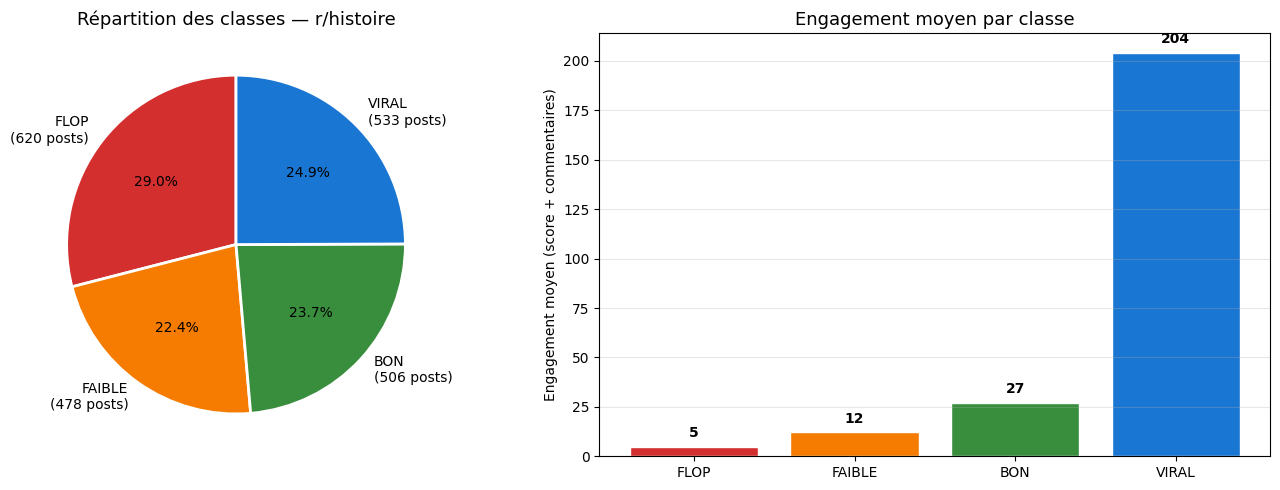

In [ ]:
"""Cellule 4 - Classification des posts par niveau d'engagement.

Définit quatre classes d'engagement basées sur les quartiles de la distribution :
- Classe 0 : FLOP  (engagement <= Q1)
- Classe 1 : FAIBLE (Q1 < engagement <= médiane)
- Classe 2 : BON   (médiane < engagement <= Q3)
- Classe 3 : VIRAL (engagement > Q3)
Génère un graphique en camembert et un barplot de l'engagement moyen par classe.
"""


# CELLULE 4 — CLASSES D'ENGAGEMENT (basées sur les quartiles)


q1  = df['engagement'].quantile(0.25)
med = df['engagement'].quantile(0.50)
q3  = df['engagement'].quantile(0.75)

print(f'Quartiles de l\'engagement :')
print(f'  Q1  (25%) : {q1:.0f}')
print(f'  Med (50%) : {med:.0f}')
print(f'  Q3  (75%) : {q3:.0f}')

def definir_classe(eng):
    if eng <= q1:  return 0  # FLOP
    elif eng <= med: return 1  # FAIBLE
    elif eng <= q3:  return 2  # BON
    else:            return 3  # VIRAL

df['classe_engagement'] = df['engagement'].apply(definir_classe)
labels_classes   = {0: 'FLOP', 1: 'FAIBLE', 2: 'BON', 3: 'VIRAL'}
couleurs_classes = ['#d32f2f', '#f57c00', '#388e3c', '#1976d2']
classes_info     = [(0,'FLOP','Reds'), (1,'FAIBLE','Blues'), (2,'BON','Greens'), (3,'VIRAL','Oranges')]

print(f'\nDistribution des classes :')
for c in range(4):
    n   = len(df[df['classe_engagement'] == c])
    pct = n / len(df) * 100
    eng_moy = df[df['classe_engagement'] == c]['engagement'].mean()
    print(f'  {labels_classes[c]:<7} : {n:4d} posts ({pct:.1f}%) | engagement moyen = {eng_moy:.0f}')

# Graphique répartition des classes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tailles    = [len(df[df['classe_engagement'] == c]) for c in range(4)]
labels_pie = [f"{labels_classes[c]}\n({tailles[c]} posts)" for c in range(4)]
axes[0].pie(tailles, labels=labels_pie, colors=couleurs_classes,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'Répartition des classes — r/{NOM_SUBREDDIT}', fontsize=13)

eng_par_classe = df.groupby('classe_engagement')['engagement'].mean()
axes[1].bar([labels_classes[c] for c in eng_par_classe.index],
            eng_par_classe.values, color=couleurs_classes, edgecolor='white')
axes[1].set_title('Engagement moyen par classe', fontsize=13)
axes[1].set_ylabel('Engagement moyen (score + commentaires)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eng_par_classe.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('classes_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

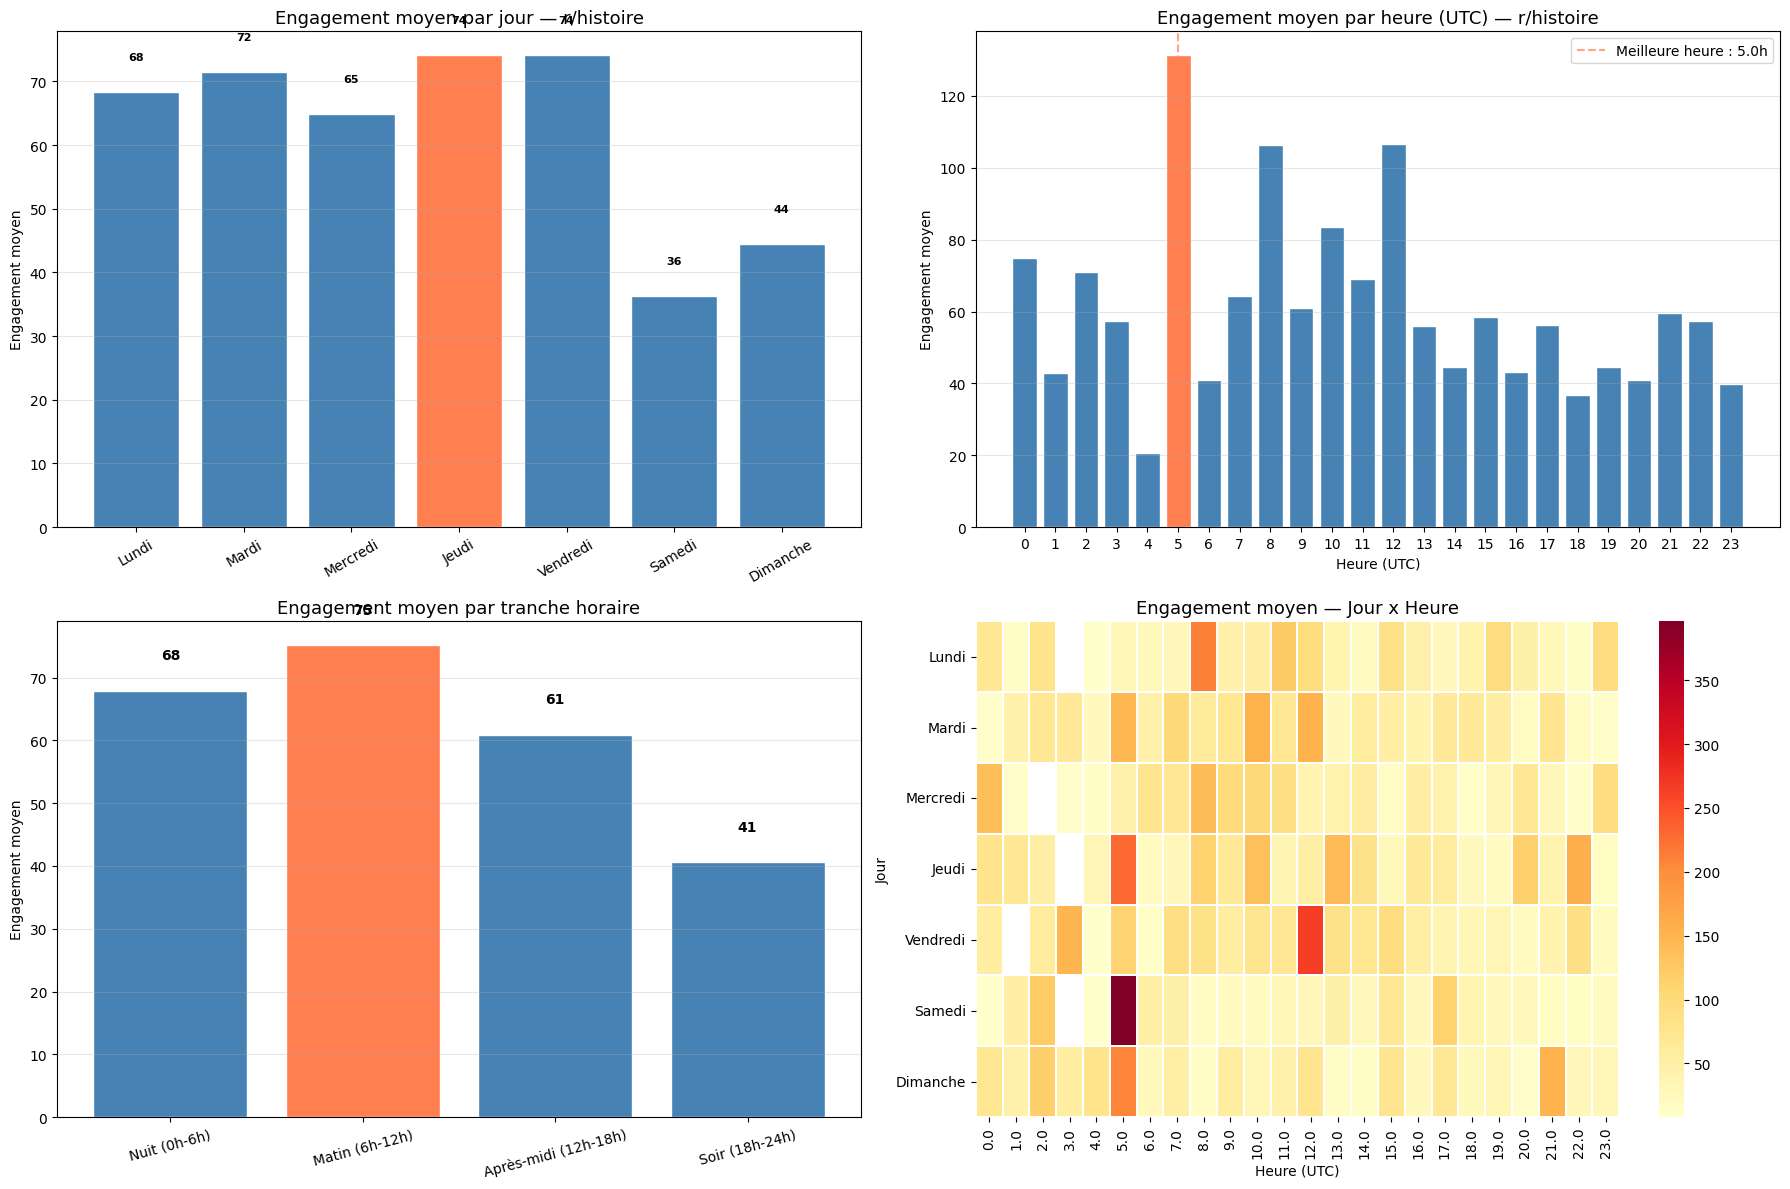

Meilleure heure : 5.0h UTC (engagement moyen : 131)

Engagement moyen par jour :
  Lundi      : 68
  Mardi      : 72
  Mercredi   : 65
  Jeudi      : 74
  Vendredi   : 74
  Samedi     : 36
  Dimanche   : 44


In [ ]:
"""Cellule 5 - Analyse temporelle : jour de la semaine et heure de publication.

Produit quatre graphiques :
- Engagement moyen par jour de la semaine.
- Engagement moyen par heure UTC.
- Engagement moyen par tranche horaire (nuit, matin, après-midi, soir).
- Heatmap croisée jour x heure.
Sauvegarde la figure sous temporel_jour_heure.png.
"""


# CELLULE 5 — ANALYSE TEMPORELLE : JOUR ET HEURE
jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
jours_fr    = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graphique 1 — Engagement moyen par jour
eng_par_jour = df.groupby('nom_jour')['engagement'].mean().reindex(jours_ordre)
couleurs_j   = ['coral' if v == eng_par_jour.max() else 'steelblue' for v in eng_par_jour.values]
axes[0,0].bar(jours_fr, eng_par_jour.values, color=couleurs_j, edgecolor='white')
axes[0,0].set_title(f'Engagement moyen par jour — r/{NOM_SUBREDDIT}', fontsize=13)
axes[0,0].set_ylabel('Engagement moyen')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eng_par_jour.values):
    axes[0,0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')

# Graphique 2 — Engagement moyen par heure
eng_par_heure = df.groupby('heure')['engagement'].mean()
couleurs_h    = ['coral' if v == eng_par_heure.max() else 'steelblue' for v in eng_par_heure.values]
axes[0,1].bar(eng_par_heure.index, eng_par_heure.values, color=couleurs_h, edgecolor='white')
axes[0,1].axvline(x=eng_par_heure.idxmax(), color='coral', linestyle='--', alpha=0.7,
                  label=f'Meilleure heure : {eng_par_heure.idxmax()}h')
axes[0,1].set_title(f'Engagement moyen par heure (UTC) — r/{NOM_SUBREDDIT}', fontsize=13)
axes[0,1].set_xlabel('Heure (UTC)')
axes[0,1].set_ylabel('Engagement moyen')
axes[0,1].set_xticks(range(0, 24))
axes[0,1].grid(True, alpha=0.3, axis='y')
axes[0,1].legend()

# Graphique 3 — Engagement moyen par tranche horaire
ordre_tranches = ['Nuit (0h-6h)', 'Matin (6h-12h)', 'Après-midi (12h-18h)', 'Soir (18h-24h)']
eng_tranche    = df.groupby('tranche_horaire')['engagement'].mean().reindex(ordre_tranches)
couleurs_t     = ['coral' if v == eng_tranche.max() else 'steelblue' for v in eng_tranche.values]
axes[1,0].bar(ordre_tranches, eng_tranche.values, color=couleurs_t, edgecolor='white')
axes[1,0].set_title('Engagement moyen par tranche horaire', fontsize=13)
axes[1,0].set_ylabel('Engagement moyen')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eng_tranche.values):
    axes[1,0].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Graphique 4 — Heatmap jour x heure
pivot = df.pivot_table(values='engagement', index='nom_jour',
                       columns='heure', aggfunc='mean').reindex(jours_ordre)
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd', linewidths=0.3)
axes[1,1].set_title('Engagement moyen — Jour x Heure', fontsize=13)
axes[1,1].set_xlabel('Heure (UTC)')
axes[1,1].set_ylabel('Jour')
axes[1,1].set_yticklabels(jours_fr, rotation=0)

plt.tight_layout()
plt.savefig('temporel_jour_heure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Meilleure heure : {eng_par_heure.idxmax()}h UTC (engagement moyen : {eng_par_heure.max():.0f})')
print(f'\nEngagement moyen par jour :')
for j, jf, v in zip(jours_ordre, jours_fr, eng_par_jour.values):
    print(f'  {jf:<10} : {v:.0f}')

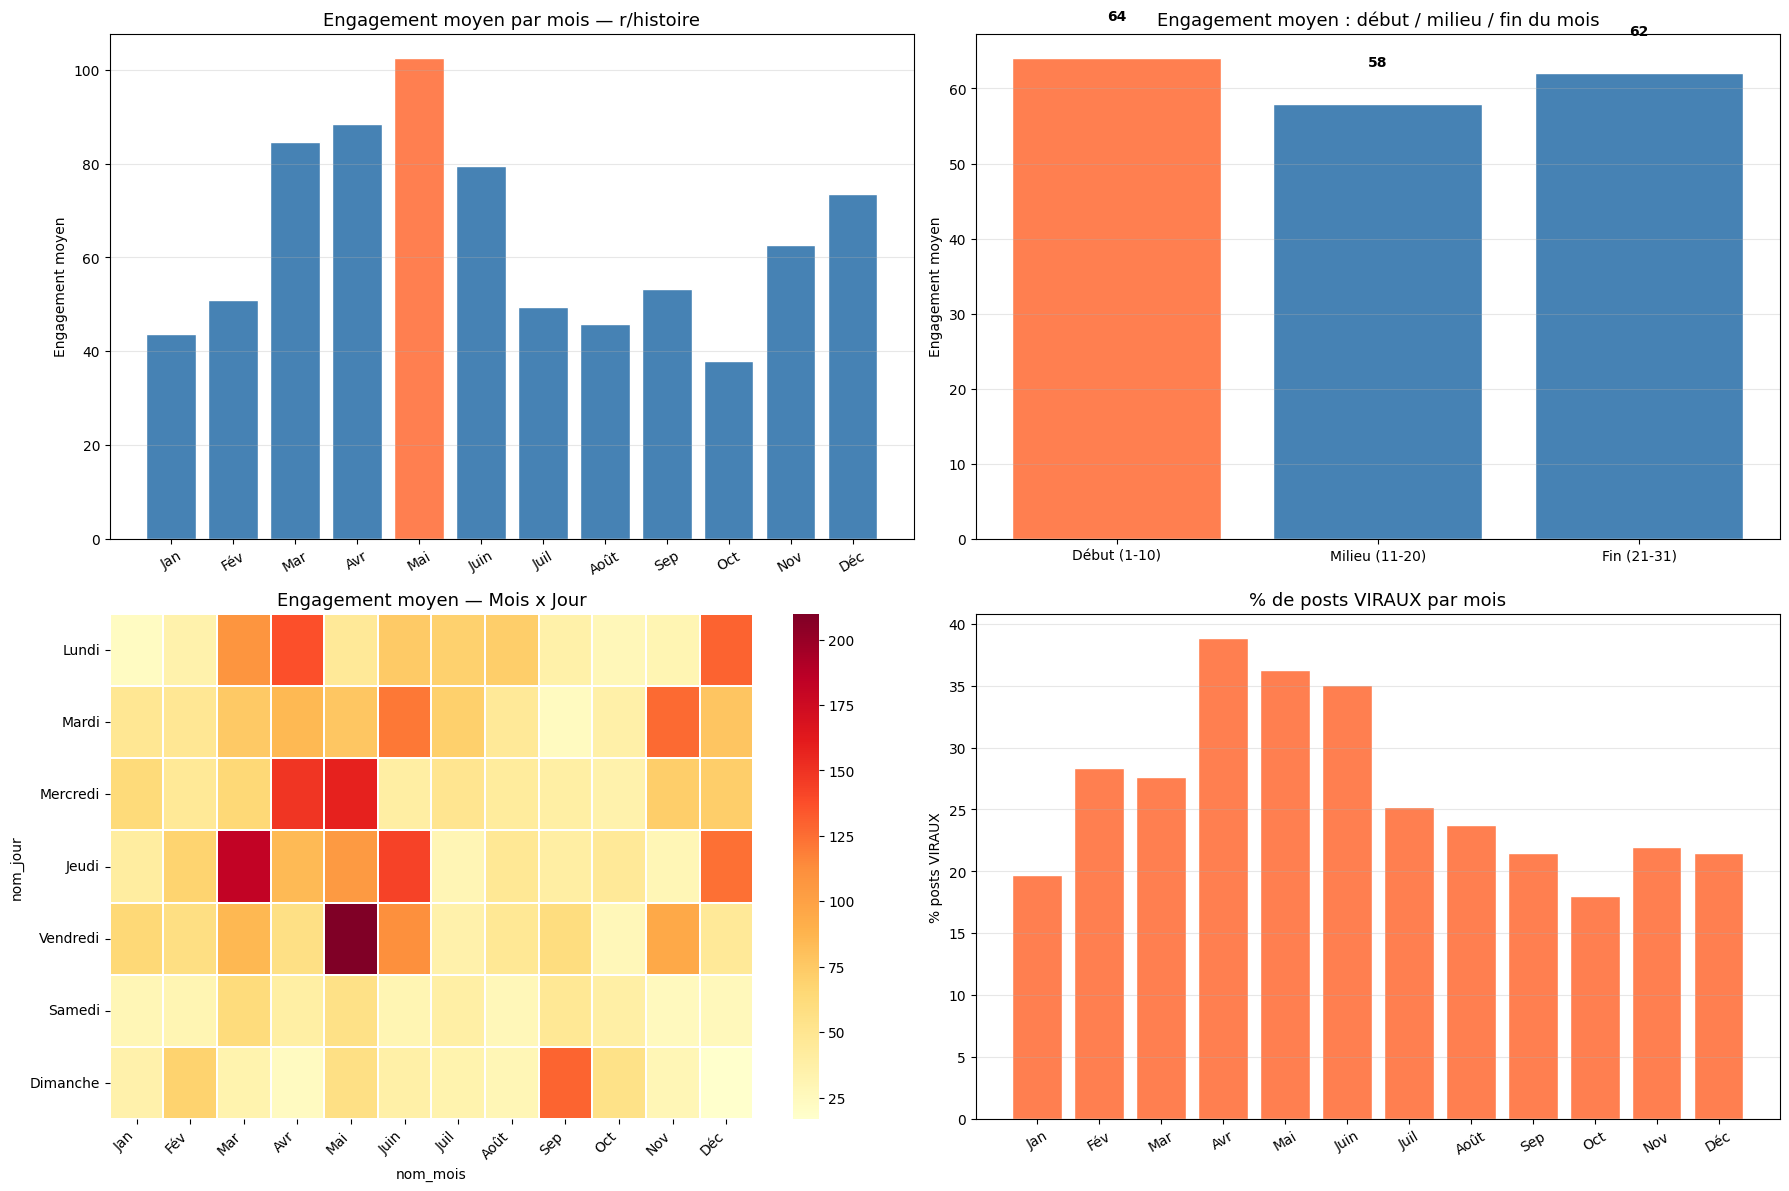

Engagement moyen par mois :
  Jan    : 44
  Fév    : 51
  Mar    : 85
  Avr    : 88
  Mai    : 103
  Juin   : 80
  Juil   : 49
  Août   : 46
  Sep    : 53
  Oct    : 38
  Nov    : 63
  Déc    : 74

Engagement par période du mois :
  Début (1-10) : 64
  Milieu (11-20) : 58
  Fin (21-31) : 62


In [ ]:
"""Cellule 6 - Analyse temporelle : mois et période du mois.

Produit quatre graphiques :
- Engagement moyen par mois.
- Engagement moyen selon la période du mois (début, milieu, fin).
- Heatmap croisée mois x jour.
- Pourcentage de posts VIRAUX par mois.
Sauvegarde la figure sous temporel_mois.png.
"""


# CELLULE 6 — ANALYSE TEMPORELLE : MOIS ET PÉRIODE DU MOIS
mois_ordre = ['January','February','March','April','May','June',
              'July','August','September','October','November','December']
mois_fr    = ['Jan','Fév','Mar','Avr','Mai','Juin',
              'Juil','Août','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Graphique 1 — Engagement moyen par mois
eng_par_mois = df.groupby('nom_mois')['engagement'].mean().reindex(mois_ordre)
couleurs_m   = ['coral' if v == eng_par_mois.max() else 'steelblue' for v in eng_par_mois.values]
axes[0,0].bar(mois_fr, eng_par_mois.values, color=couleurs_m, edgecolor='white')
axes[0,0].set_title(f'Engagement moyen par mois — r/{NOM_SUBREDDIT}', fontsize=13)
axes[0,0].set_ylabel('Engagement moyen')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(True, alpha=0.3, axis='y')

# Graphique 2 — Début / milieu / fin du mois
ordre_periode  = ['Début (1-10)', 'Milieu (11-20)', 'Fin (21-31)']
eng_periode    = df.groupby('semaine_mois')['engagement'].mean().reindex(ordre_periode)
couleurs_p     = ['coral' if v == eng_periode.max() else 'steelblue' for v in eng_periode.values]
axes[0,1].bar(ordre_periode, eng_periode.values, color=couleurs_p, edgecolor='white')
axes[0,1].set_title('Engagement moyen : début / milieu / fin du mois', fontsize=13)
axes[0,1].set_ylabel('Engagement moyen')
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eng_periode.values):
    axes[0,1].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Graphique 3 — Heatmap mois x jour
pivot_mj = df.pivot_table(values='engagement', index='nom_jour',
                           columns='nom_mois', aggfunc='mean').reindex(jours_ordre)[mois_ordre]
sns.heatmap(pivot_mj, ax=axes[1,0], cmap='YlOrRd', linewidths=0.3)
axes[1,0].set_title('Engagement moyen — Mois x Jour', fontsize=13)
axes[1,0].set_yticklabels(jours_fr, rotation=0)
axes[1,0].set_xticklabels(mois_fr, rotation=45, ha='right')

# Graphique 4 — % posts VIRAUX par mois
viral_mois = df[df['classe_engagement'] == 3].groupby('nom_mois').size().reindex(mois_ordre).fillna(0)
total_mois = df.groupby('nom_mois').size().reindex(mois_ordre).fillna(1)
pct_viral  = (viral_mois / total_mois * 100)
axes[1,1].bar(mois_fr, pct_viral.values, color='coral', edgecolor='white')
axes[1,1].set_title('% de posts VIRAUX par mois', fontsize=13)
axes[1,1].set_ylabel('% posts VIRAUX')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('temporel_mois.png', dpi=150, bbox_inches='tight')
plt.show()

print('Engagement moyen par mois :')
for mf, v in zip(mois_fr, eng_par_mois.values):
    print(f'  {mf:<6} : {v:.0f}')
print('\nEngagement par période du mois :')
for p, v in eng_periode.items():
    print(f'  {p} : {v:.0f}')

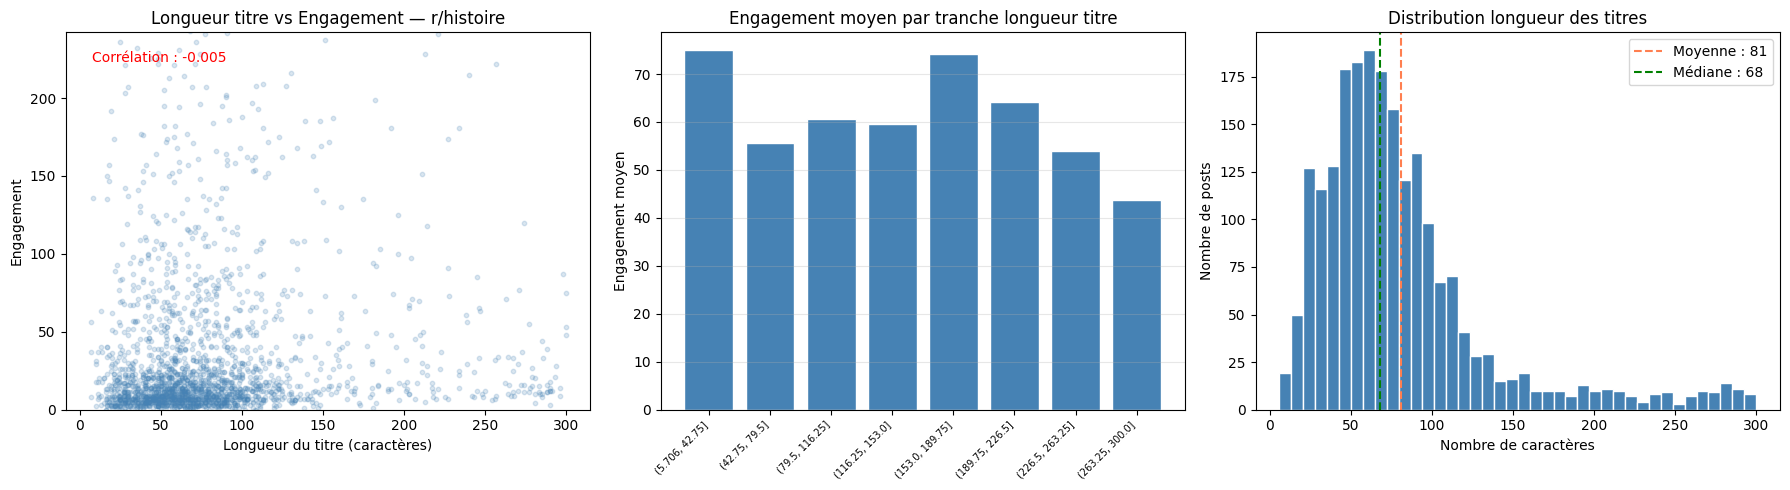

Longueur titre moyenne : 81 caractères
Corrélation longueur titre / engagement : -0.005


In [ ]:
"""Cellule 7 - Analyse de la longueur du titre.

Explore la relation entre la longueur du titre (en caractères) et l'engagement :
- Nuage de points longueur titre vs engagement avec coefficient de corrélation.
- Engagement moyen par tranche de longueur.
- Distribution de la longueur des titres avec moyenne et médiane.
Sauvegarde la figure sous longueur_titre.png.
"""


# CELLULE 7 — LONGUEUR DU TITRE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Graphique 1 — Scatter longueur titre vs engagement
axes[0].scatter(df['longueur_titre'], df['engagement'], alpha=0.2, color='steelblue', s=10)
axes[0].set_title(f'Longueur titre vs Engagement — r/{NOM_SUBREDDIT}', fontsize=12)
axes[0].set_xlabel('Longueur du titre (caractères)')
axes[0].set_ylabel('Engagement')
axes[0].set_ylim(0, df['engagement'].quantile(0.95))
corr_lt = df['longueur_titre'].corr(df['engagement'])
axes[0].text(0.05, 0.95, f'Corrélation : {corr_lt:.3f}',
             transform=axes[0].transAxes, color='red', fontsize=10, va='top')

# Graphique 2 — Engagement moyen par tranche de longueur
df['tranche_titre'] = pd.cut(df['longueur_titre'], bins=8)
eng_par_tranche_t   = df.groupby('tranche_titre', observed=True)['engagement'].mean()
axes[1].bar(range(len(eng_par_tranche_t)), eng_par_tranche_t.values,
            color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(eng_par_tranche_t)))
axes[1].set_xticklabels([str(i) for i in eng_par_tranche_t.index],
                         rotation=45, ha='right', fontsize=7)
axes[1].set_title('Engagement moyen par tranche longueur titre', fontsize=12)
axes[1].set_ylabel('Engagement moyen')
axes[1].grid(True, alpha=0.3, axis='y')

# Graphique 3 — Distribution longueur titre
axes[2].hist(df['longueur_titre'], bins=40, color='steelblue', edgecolor='white')
axes[2].axvline(df['longueur_titre'].mean(), color='coral', linestyle='--',
                label=f"Moyenne : {df['longueur_titre'].mean():.0f}")
axes[2].axvline(df['longueur_titre'].median(), color='green', linestyle='--',
                label=f"Médiane : {df['longueur_titre'].median():.0f}")
axes[2].set_title('Distribution longueur des titres', fontsize=12)
axes[2].set_xlabel('Nombre de caractères')
axes[2].set_ylabel('Nombre de posts')
axes[2].legend()

plt.tight_layout()
plt.savefig('longueur_titre.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Longueur titre moyenne : {df['longueur_titre'].mean():.0f} caractères")
print(f"Corrélation longueur titre / engagement : {corr_lt:.3f}")

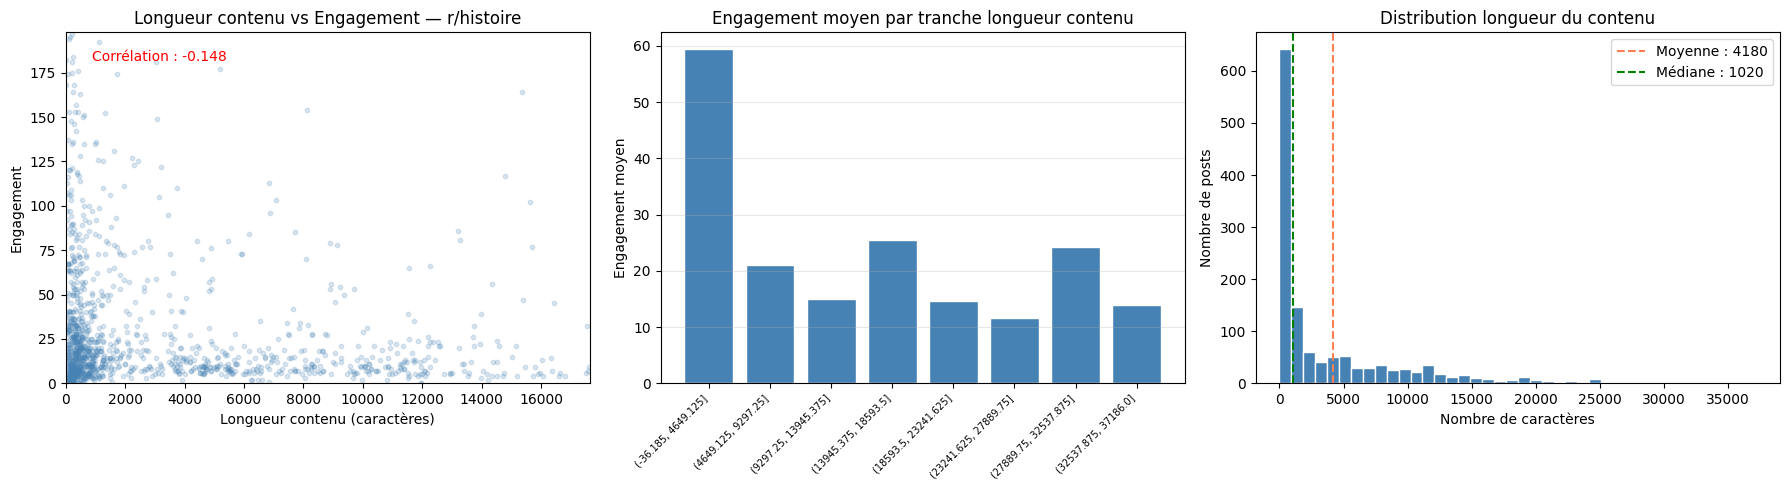

Longueur contenu moyenne : 4180 caractères
Corrélation longueur contenu / engagement : -0.148


In [ ]:
"""Cellule 8 - Analyse de la longueur du contenu.

Même analyse que la cellule 7, mais portant sur la longueur du corps du post.
Seuls les posts ayant un contenu non vide sont pris en compte.
Sauvegarde la figure sous longueur_contenu.png.
"""


# CELLULE 8 — LONGUEUR DU CONTENU
df_c = df[df['longueur_contenu'] > 0].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 — Scatter longueur contenu vs engagement
axes[0].scatter(df_c['longueur_contenu'], df_c['engagement'], alpha=0.2, color='steelblue', s=10)
axes[0].set_title(f'Longueur contenu vs Engagement — r/{NOM_SUBREDDIT}', fontsize=12)
axes[0].set_xlabel('Longueur contenu (caractères)')
axes[0].set_ylabel('Engagement')
axes[0].set_ylim(0, df_c['engagement'].quantile(0.95))
axes[0].set_xlim(0, df_c['longueur_contenu'].quantile(0.95))
corr_lc = df_c['longueur_contenu'].corr(df_c['engagement'])
axes[0].text(0.05, 0.95, f'Corrélation : {corr_lc:.3f}',
             transform=axes[0].transAxes, color='red', fontsize=10, va='top')

# Graphique 2 — Engagement moyen par tranche longueur contenu
df_c['tranche_contenu'] = pd.cut(df_c['longueur_contenu'], bins=8)
eng_par_tranche_c       = df_c.groupby('tranche_contenu', observed=True)['engagement'].mean()
axes[1].bar(range(len(eng_par_tranche_c)), eng_par_tranche_c.values,
            color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(eng_par_tranche_c)))
axes[1].set_xticklabels([str(i) for i in eng_par_tranche_c.index],
                         rotation=45, ha='right', fontsize=7)
axes[1].set_title('Engagement moyen par tranche longueur contenu', fontsize=12)
axes[1].set_ylabel('Engagement moyen')
axes[1].grid(True, alpha=0.3, axis='y')

# Graphique 3 — Distribution longueur contenu
axes[2].hist(df_c['longueur_contenu'], bins=40, color='steelblue', edgecolor='white')
axes[2].axvline(df_c['longueur_contenu'].mean(), color='coral', linestyle='--',
                label=f"Moyenne : {df_c['longueur_contenu'].mean():.0f}")
axes[2].axvline(df_c['longueur_contenu'].median(), color='green', linestyle='--',
                label=f"Médiane : {df_c['longueur_contenu'].median():.0f}")
axes[2].set_title('Distribution longueur du contenu', fontsize=12)
axes[2].set_xlabel('Nombre de caractères')
axes[2].set_ylabel('Nombre de posts')
axes[2].legend()

plt.tight_layout()
plt.savefig('longueur_contenu.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Longueur contenu moyenne : {df_c['longueur_contenu'].mean():.0f} caractères")
print(f"Corrélation longueur contenu / engagement : {corr_lc:.3f}")

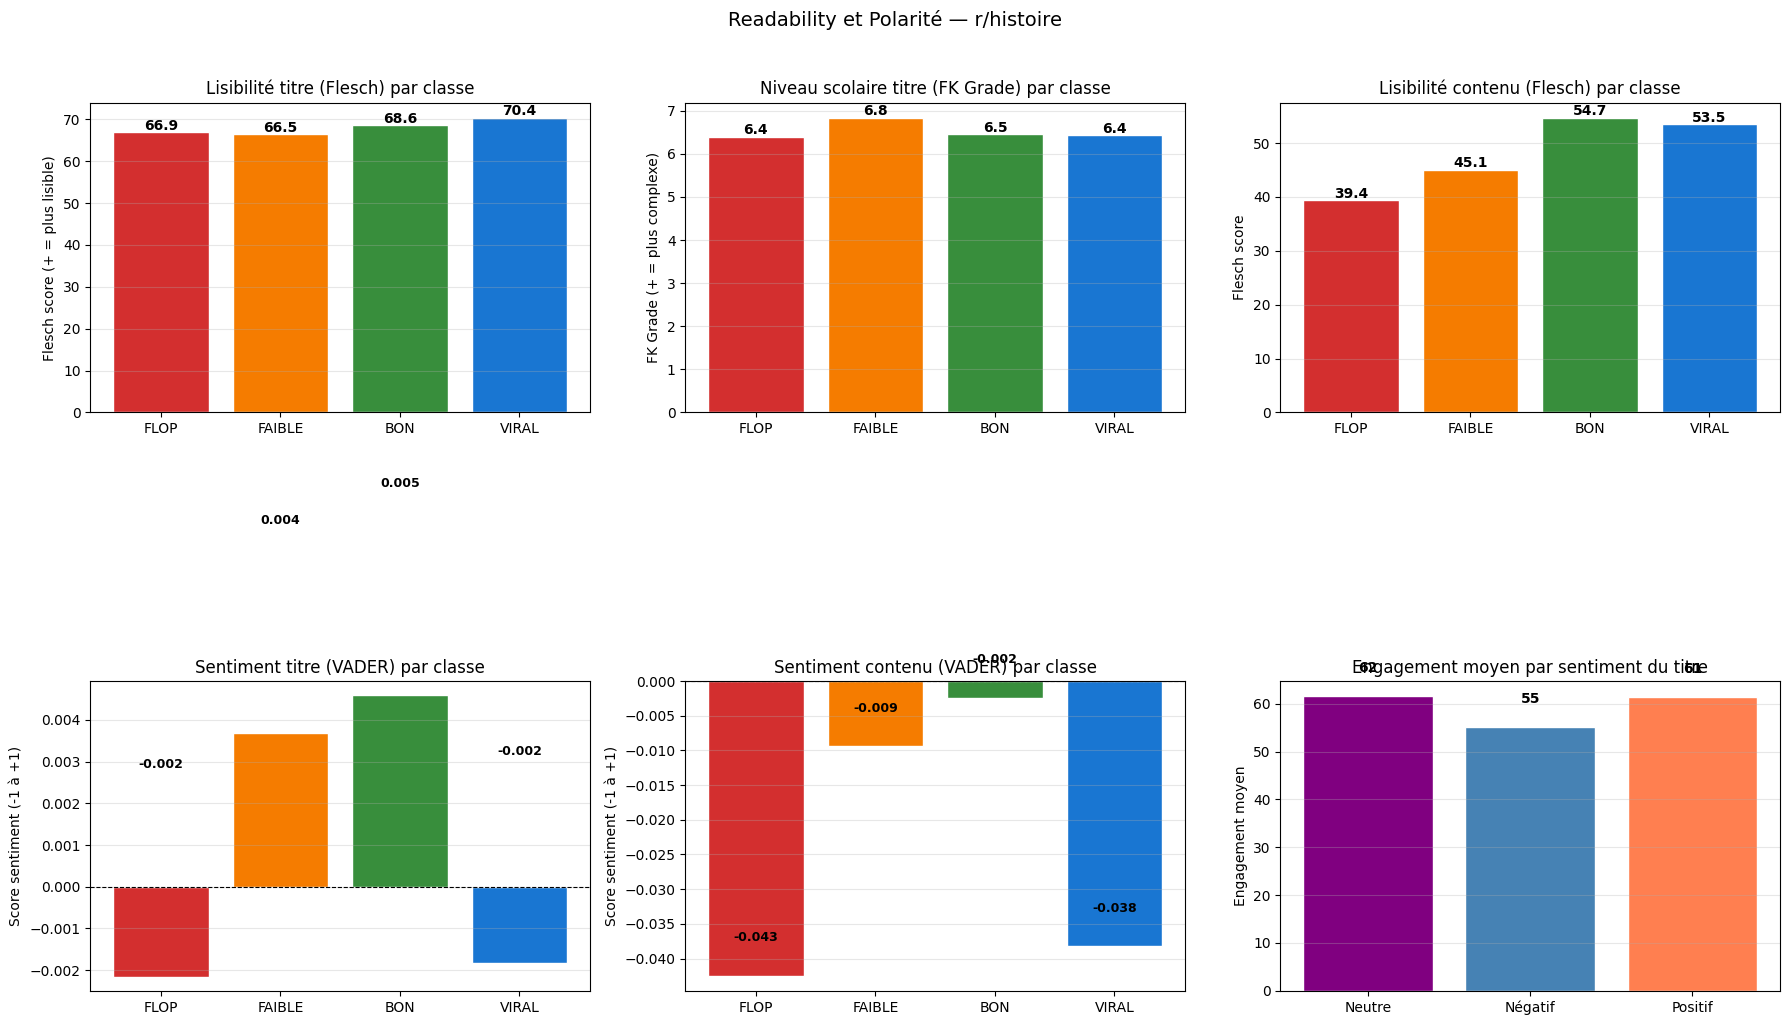

Flesch titre moyen  : 68.09
FK Grade moyen      : 6.53
Corrélation Flesch / engagement : 0.059
Corrélation sentiment / engagement : -0.005


In [ ]:
"""Cellule 9 - Lisibilité (Flesch / FK Grade) et polarité (VADER).

Calcule pour chaque post :
- Le score de lisibilité Flesch et le niveau scolaire Flesch-Kincaid du titre et du contenu.
- Le score de sentiment VADER du titre et du contenu, ainsi qu'une catégorie (Positif / Neutre / Négatif).
Génère six graphiques comparant ces métriques par classe d'engagement.
Sauvegarde la figure sous readability_polarite.png.
"""


# CELLULE 9 — READABILITY ET POLARITÉ (VADER)
import textstat
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Readability
df['flesch_titre']   = df['titre'].apply(lambda x: textstat.flesch_reading_ease(str(x)))
df['fk_grade_titre'] = df['titre'].apply(lambda x: textstat.flesch_kincaid_grade(str(x)))
df['flesch_contenu'] = df['contenu'].fillna('').apply(
    lambda x: textstat.flesch_reading_ease(str(x)) if len(str(x)) > 10 else None
)

# Sentiment VADER
analyzer = SentimentIntensityAnalyzer()
df['sentiment_titre']   = df['titre'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound'])
df['sentiment_contenu_score'] = df['contenu'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))['compound'])
df['sentiment_cat'] = df['sentiment_titre'].apply(
    lambda s: 'Positif' if s > 0.05 else 'Négatif' if s < -0.05 else 'Neutre')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flesch titre par classe
flesch_cl = df.groupby('classe_engagement')['flesch_titre'].mean()
axes[0,0].bar([labels_classes[c] for c in flesch_cl.index], flesch_cl.values,
              color=couleurs_classes, edgecolor='white')
axes[0,0].set_title('Lisibilité titre (Flesch) par classe', fontsize=12)
axes[0,0].set_ylabel('Flesch score (+ = plus lisible)')
axes[0,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(flesch_cl.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# FK Grade par classe
fk_cl = df.groupby('classe_engagement')['fk_grade_titre'].mean()
axes[0,1].bar([labels_classes[c] for c in fk_cl.index], fk_cl.values,
              color=couleurs_classes, edgecolor='white')
axes[0,1].set_title('Niveau scolaire titre (FK Grade) par classe', fontsize=12)
axes[0,1].set_ylabel('FK Grade (+ = plus complexe)')
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fk_cl.values):
    axes[0,1].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

# Flesch contenu par classe
flesch_cont_cl = df.groupby('classe_engagement')['flesch_contenu'].mean()
axes[0,2].bar([labels_classes[c] for c in flesch_cont_cl.index], flesch_cont_cl.values,
              color=couleurs_classes, edgecolor='white')
axes[0,2].set_title('Lisibilité contenu (Flesch) par classe', fontsize=12)
axes[0,2].set_ylabel('Flesch score')
axes[0,2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(flesch_cont_cl.values):
    axes[0,2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# Sentiment titre par classe
sent_cl = df.groupby('classe_engagement')['sentiment_titre'].mean()
axes[1,0].bar([labels_classes[c] for c in sent_cl.index], sent_cl.values,
              color=couleurs_classes, edgecolor='white')
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].set_title('Sentiment titre (VADER) par classe', fontsize=12)
axes[1,0].set_ylabel('Score sentiment (-1 à +1)')
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sent_cl.values):
    axes[1,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# Sentiment contenu par classe
sent_cont_cl = df.groupby('classe_engagement')['sentiment_contenu_score'].mean()
axes[1,1].bar([labels_classes[c] for c in sent_cont_cl.index], sent_cont_cl.values,
              color=couleurs_classes, edgecolor='white')
axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,1].set_title('Sentiment contenu (VADER) par classe', fontsize=12)
axes[1,1].set_ylabel('Score sentiment (-1 à +1)')
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sent_cont_cl.values):
    axes[1,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# Engagement moyen par catégorie de sentiment
eng_sent = df.groupby('sentiment_cat')['engagement'].mean()
axes[1,2].bar(eng_sent.index, eng_sent.values,
              color=['purple','steelblue','coral'], edgecolor='white')
axes[1,2].set_title('Engagement moyen par sentiment du titre', fontsize=12)
axes[1,2].set_ylabel('Engagement moyen')
axes[1,2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(eng_sent.values):
    axes[1,2].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

plt.suptitle(f'Readability et Polarité — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('readability_polarite.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Flesch titre moyen  : {df['flesch_titre'].mean():.2f}")
print(f"FK Grade moyen      : {df['fk_grade_titre'].mean():.2f}")
print(f"Corrélation Flesch / engagement : {df['flesch_titre'].corr(df['engagement']):.3f}")
print(f"Corrélation sentiment / engagement : {df['sentiment_titre'].corr(df['engagement']):.3f}")

In [ ]:
"""Cellule 10 - Prétraitement du texte.

Applique un pipeline de nettoyage en quatre étapes sur les colonnes titre et contenu :
1. Nettoyage : mise en minuscules, suppression des URLs, des caractères spéciaux et des espaces multiples.
2. Suppression des stop words anglais (NLTK).
3. Lemmatisation avec spaCy (modèle en_core_web_sm).
4. Deuxième suppression des stop words après lemmatisation.
Les colonnes résultantes (titre_final, contenu_final) sont utilisées dans les cellules suivantes.
"""


# CELLULE 10 — PRÉTRAITEMENT DU TEXTE
from nltk.corpus import stopwords
import spacy

nlp        = spacy.load('en_core_web_sm')
stop_words = set(stopwords.words('english'))

def nettoyer(texte):
    if not isinstance(texte, str) or not texte.strip(): return ''
    texte = texte.lower()
    texte = re.sub(r'http\S+', '', texte)
    texte = re.sub(r'[^a-zA-Z0-9\s]', '', texte)
    return re.sub(r'\s+', ' ', texte).strip()

def suppr_stops(texte):
    return ' '.join([m for m in texte.split() if m not in stop_words])

def lemmatiser(texte):
    if not texte: return ''
    return ' '.join([t.lemma_ for t in nlp(texte) if not t.is_space])

def resuppr_stops(texte):
    if not isinstance(texte, str): return ''
    return ' '.join([m for m in texte.split() if m not in stop_words and len(m) > 1])

print('Nettoyage...')
df['titre_nettoye']   = df['titre'].apply(nettoyer)
df['contenu_nettoye'] = df['contenu'].fillna('').apply(nettoyer)

print('Suppression stop words...')
df['titre_clean']   = df['titre_nettoye'].apply(suppr_stops)
df['contenu_clean'] = df['contenu_nettoye'].apply(suppr_stops)

print('Lemmatisation...')
df['titre_lemma']   = df['titre_clean'].apply(lemmatiser)
df['contenu_lemma'] = df['contenu_clean'].apply(lemmatiser)

print('Re-suppression stops post-lemmatisation...')
df['titre_final']   = df['titre_lemma'].apply(resuppr_stops)
df['contenu_final'] = df['contenu_lemma'].apply(resuppr_stops)

print('\nExemple de transformation :')
for i in range(2):
    print(f"  Original  : {df['titre'].iloc[i]}")
    print(f"  Final     : {df['titre_final'].iloc[i]}")
    print()

Nettoyage...
Suppression stop words...
Lemmatisation...
Re-suppression stops post-lemmatisation...

Exemple de transformation :
  Original  : Dernier homme exécuté suite à une condamnation à mort, par région de France
  Final     : derni homme excut suite une condamnation mort par rgion de france

  Original  : Les survivants de la photographie des « enfants d'Auschwitz », prise un jour comme aujourd'hui, le 27 janvier, mais en 1945...
  Final     : les survivant de la photographie des enfant dauschwitz prise un jour comme aujourdhui le 27 janvier mais en 1945



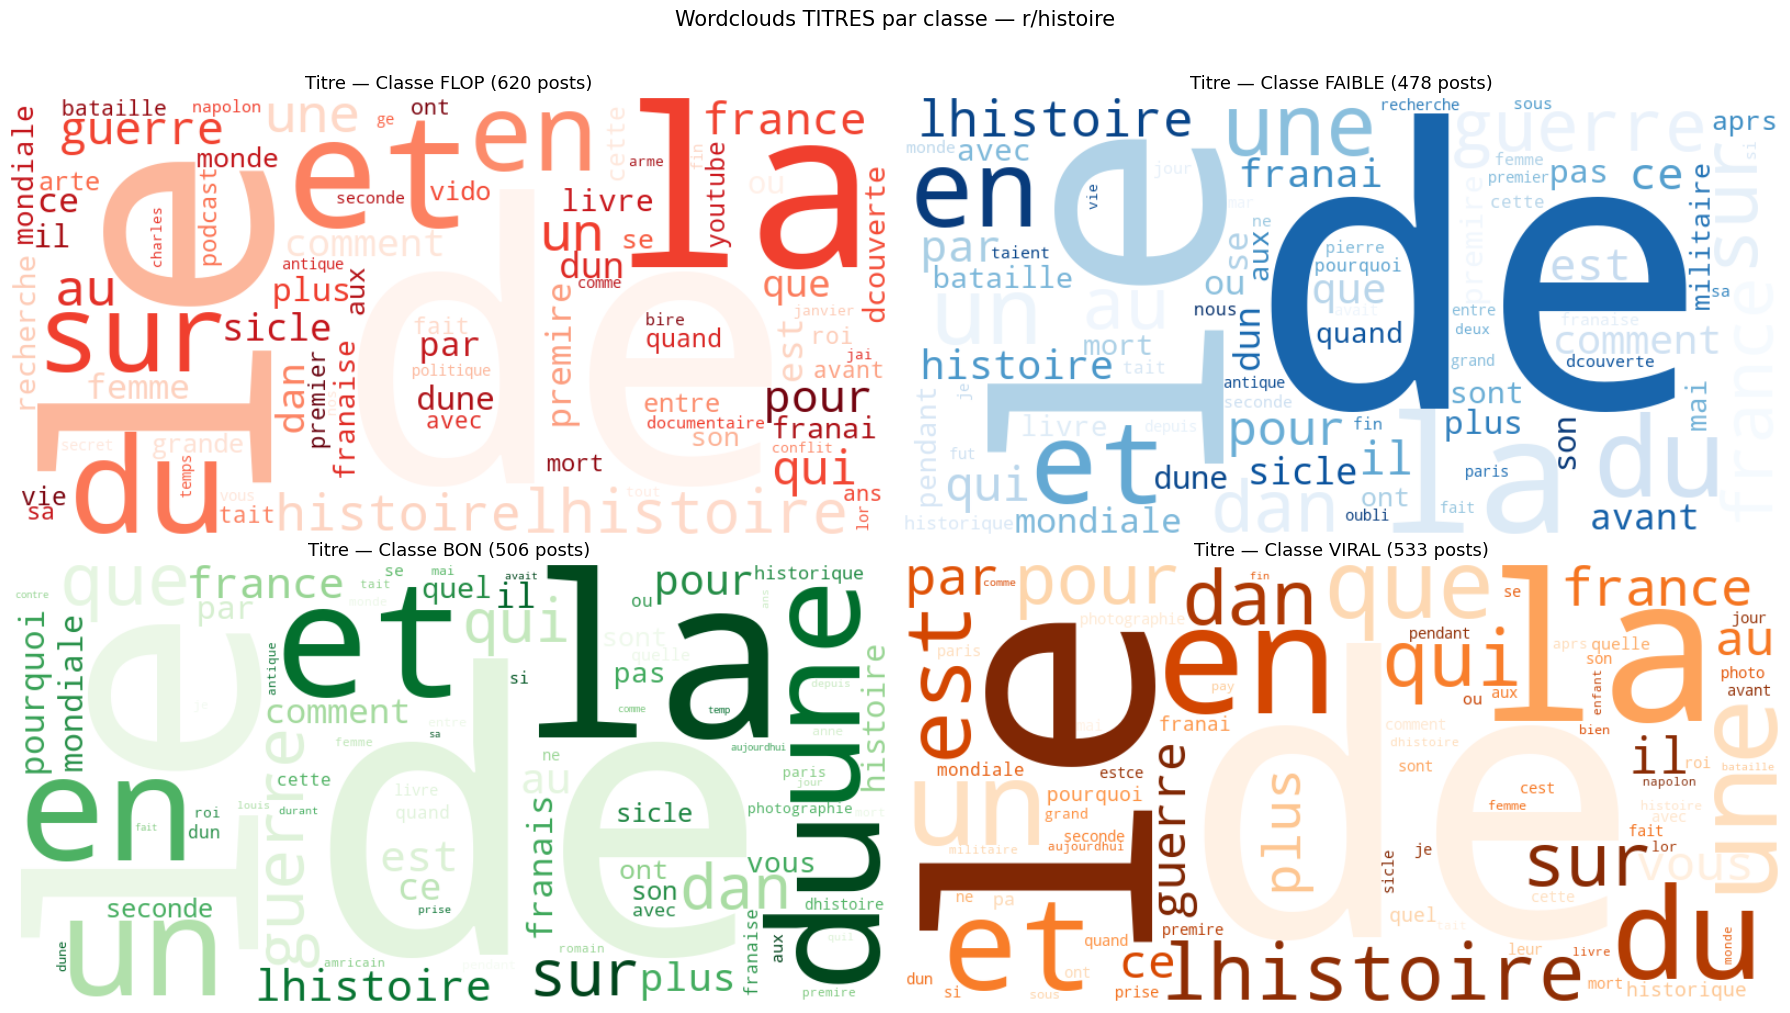

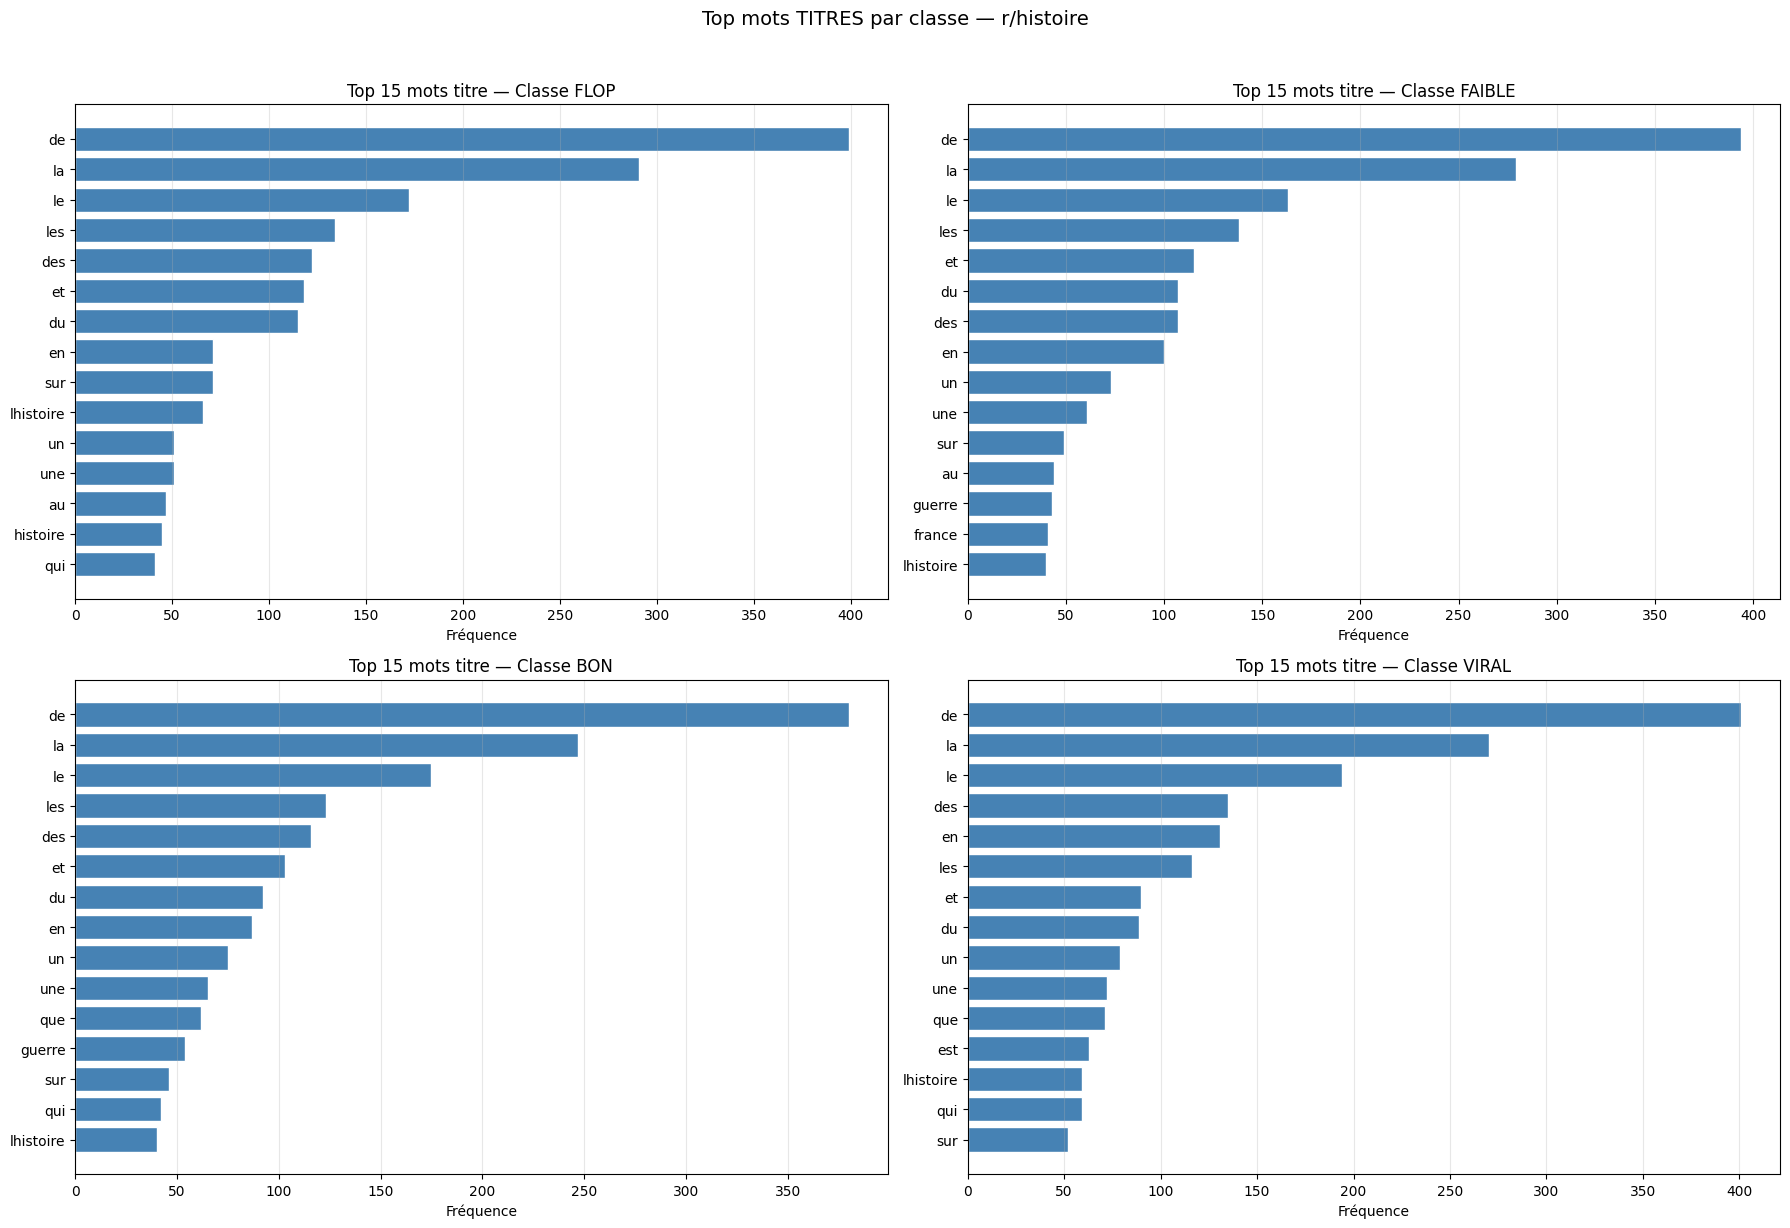

In [ ]:
"""Cellule 11 - Wordclouds et top mots par classe (titres).

Génère pour chaque classe d'engagement :
- Un wordcloud des mots les plus fréquents dans les titres.
- Un barplot horizontal des 15 mots les plus fréquents dans les titres.
Sauvegarde les figures sous wordclouds_titres.png et top_mots_titres.png.
"""


# CELLULE 11 — WORDCLOUDS ET TOP MOTS PAR CLASSE (TITRE)
from wordcloud import WordCloud
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    texte = ' '.join(df[df['classe_engagement'] == classe]['titre_final'])
    if not texte.strip():
        ax.text(0.5, 0.5, 'Pas assez de données', ha='center', va='center')
        continue
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(texte)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Titre — Classe {label} ({len(df[df["classe_engagement"]==classe])} posts)', fontsize=13)
plt.suptitle(f'Wordclouds TITRES par classe — r/{NOM_SUBREDDIT}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('wordclouds_titres.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    mots     = ' '.join(df[df['classe_engagement'] == classe]['titre_final']).split()
    top_mots = Counter(mots).most_common(15)
    if not top_mots: continue
    ax.barh([m[0] for m in top_mots][::-1], [m[1] for m in top_mots][::-1],
            color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 mots titre — Classe {label}', fontsize=12)
    ax.set_xlabel('Fréquence')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Top mots TITRES par classe — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('top_mots_titres.png', dpi=150, bbox_inches='tight')
plt.show()

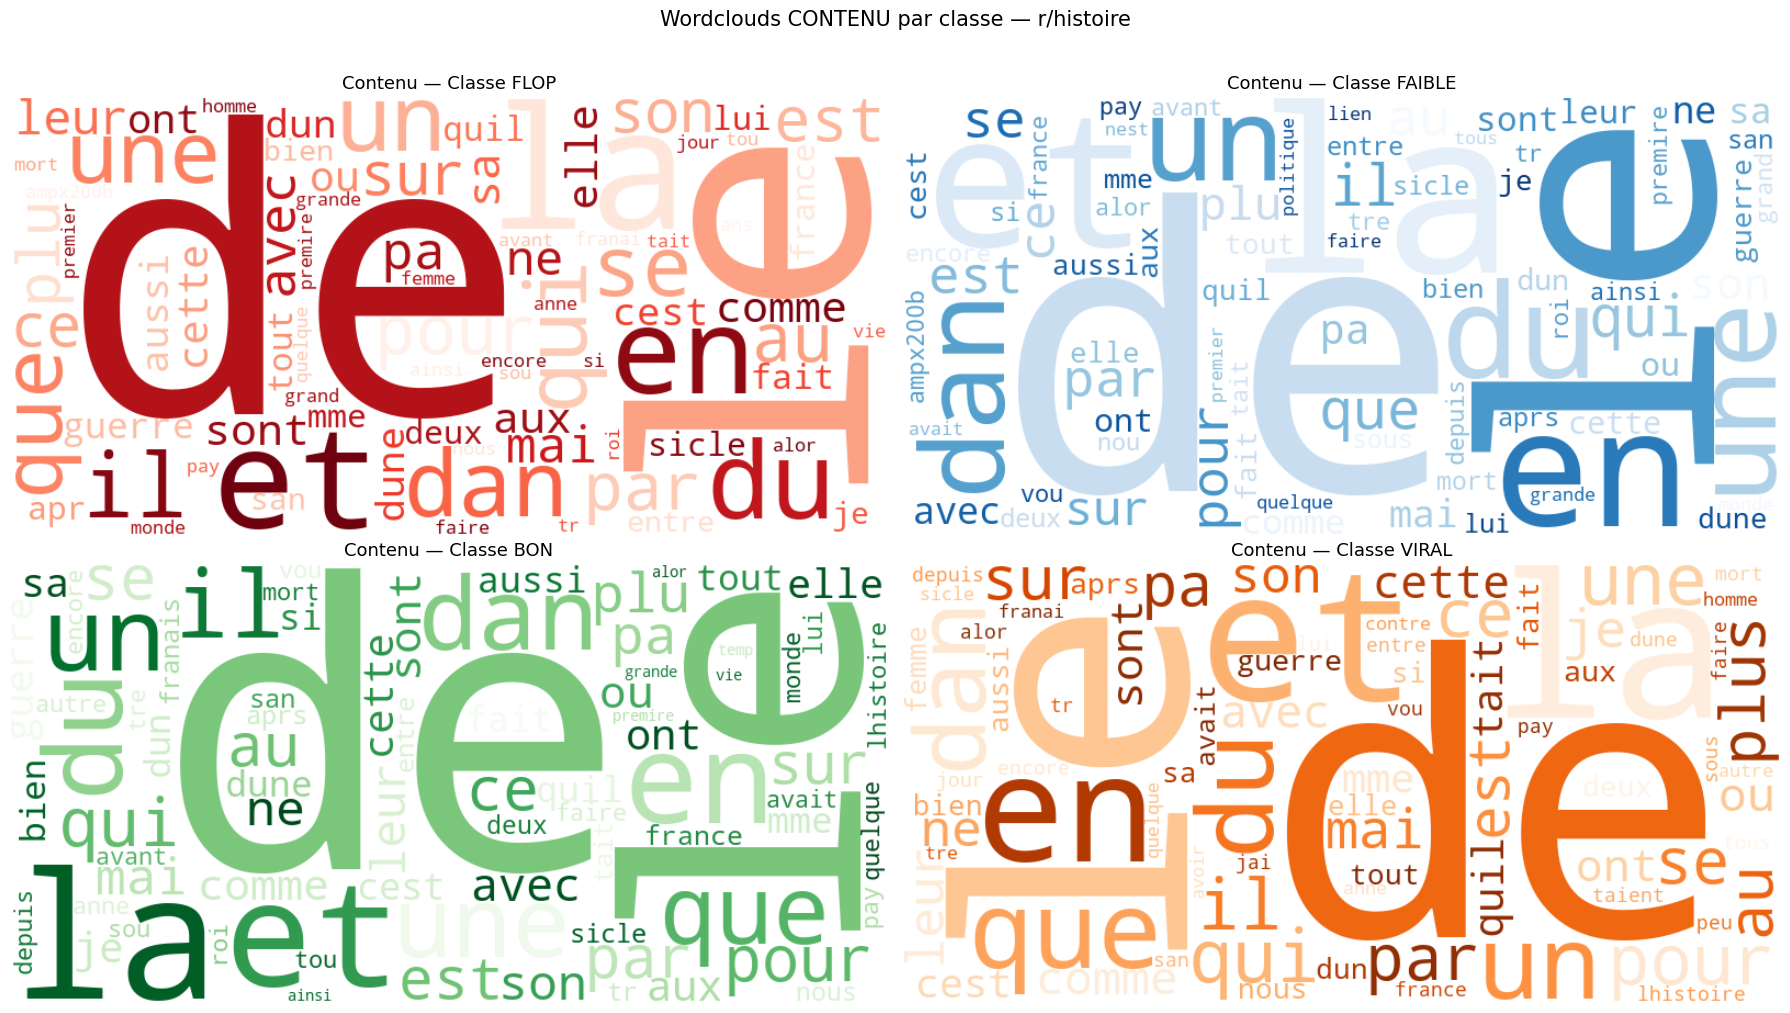

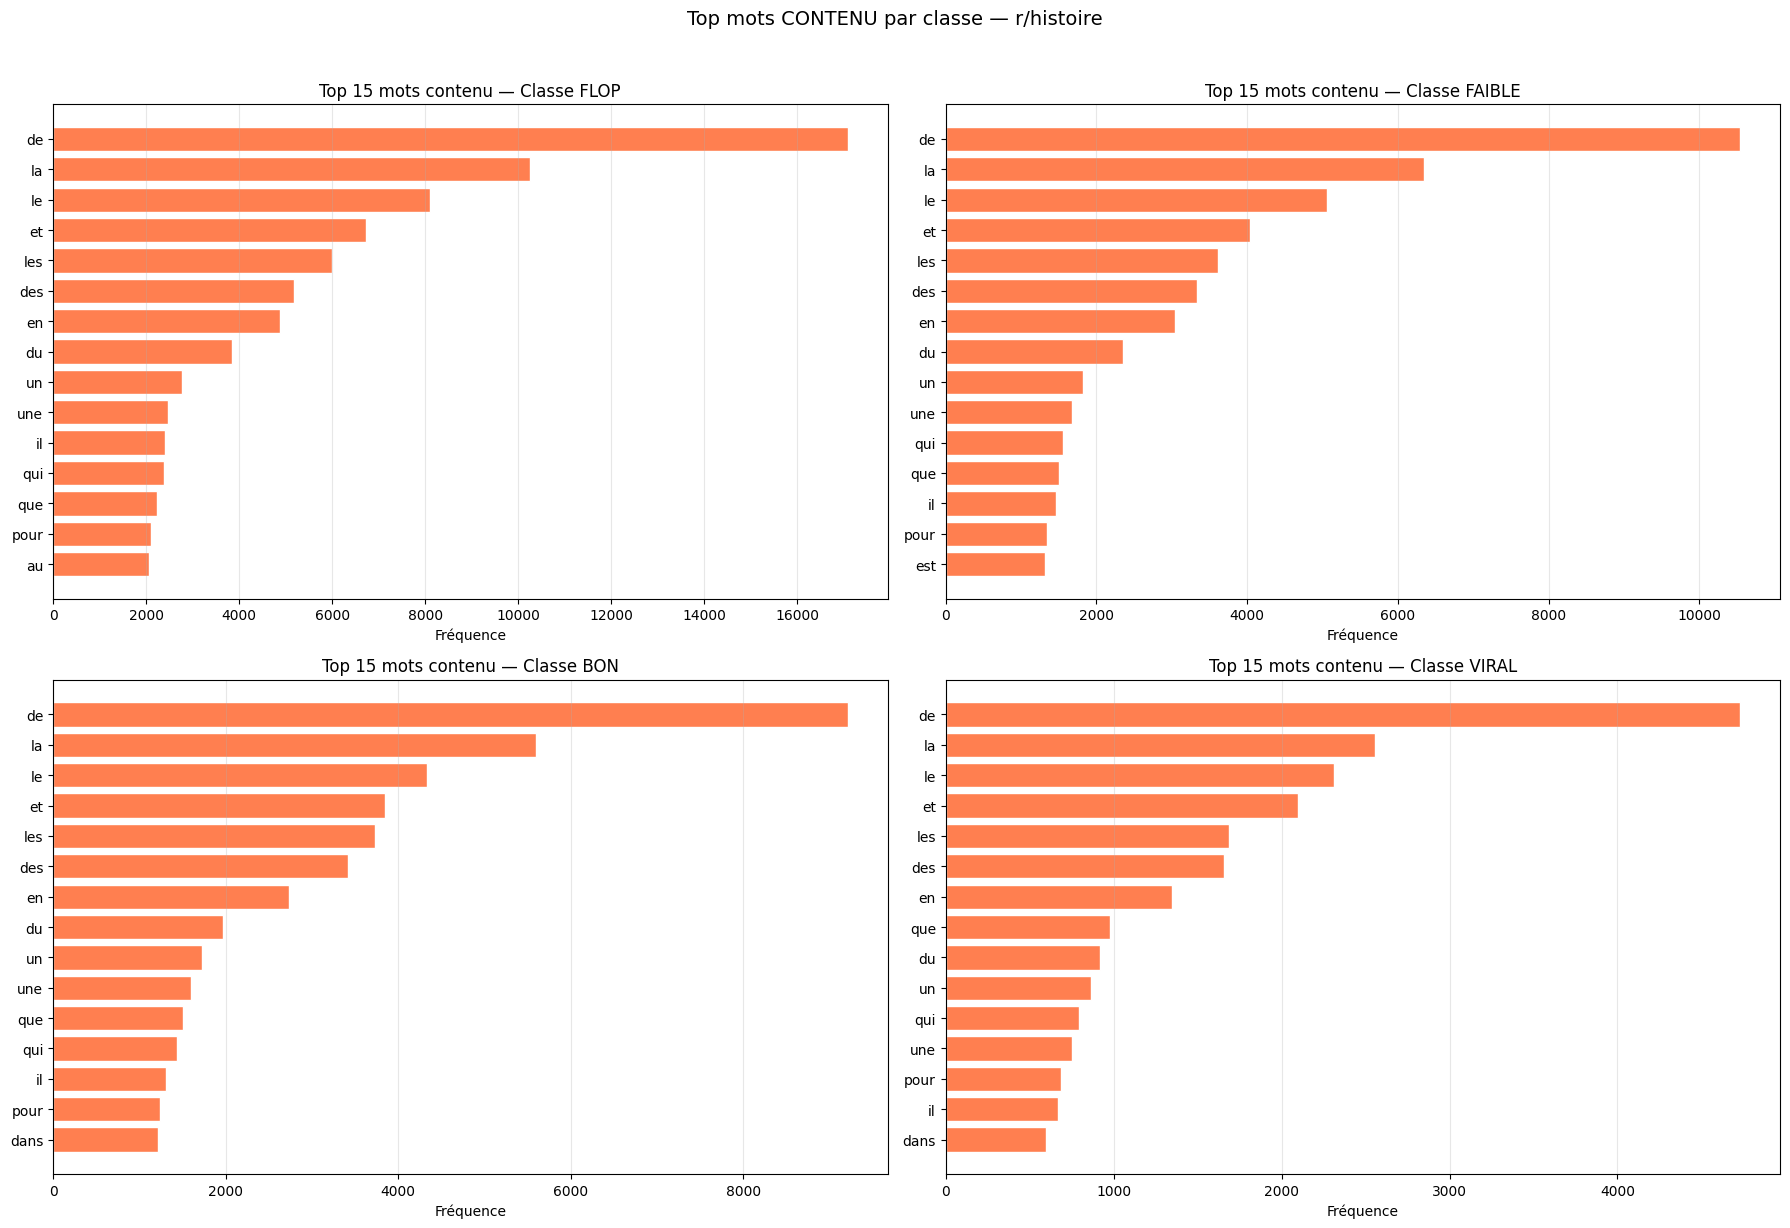

In [ ]:
"""Cellule 12 - Wordclouds et top mots par classe (contenu).

Même analyse que la cellule 11, appliquée au corps des posts.
Seuls les posts ayant un contenu non vide sont pris en compte.
Sauvegarde les figures sous wordclouds_contenu.png et top_mots_contenu.png.
"""


# CELLULE 12 — WORDCLOUDS ET TOP MOTS PAR CLASSE (CONTENU)
from wordcloud import WordCloud
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    texte = ' '.join(df[df['classe_engagement'] == classe]['contenu_final'].fillna(''))
    if len(texte.strip()) < 50:
        ax.text(0.5, 0.5, 'Pas assez de contenu', ha='center', va='center')
        ax.axis('off')
        continue
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(texte)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Contenu — Classe {label}', fontsize=13)
plt.suptitle(f'Wordclouds CONTENU par classe — r/{NOM_SUBREDDIT}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('wordclouds_contenu.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    mots     = ' '.join(df[df['classe_engagement'] == classe]['contenu_final'].fillna('')).split()
    top_mots = Counter(mots).most_common(15)
    if not top_mots: continue
    ax.barh([m[0] for m in top_mots][::-1], [m[1] for m in top_mots][::-1],
            color='coral', edgecolor='white')
    ax.set_title(f'Top 15 mots contenu — Classe {label}', fontsize=12)
    ax.set_xlabel('Fréquence')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Top mots CONTENU par classe — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('top_mots_contenu.png', dpi=150, bbox_inches='tight')
plt.show()

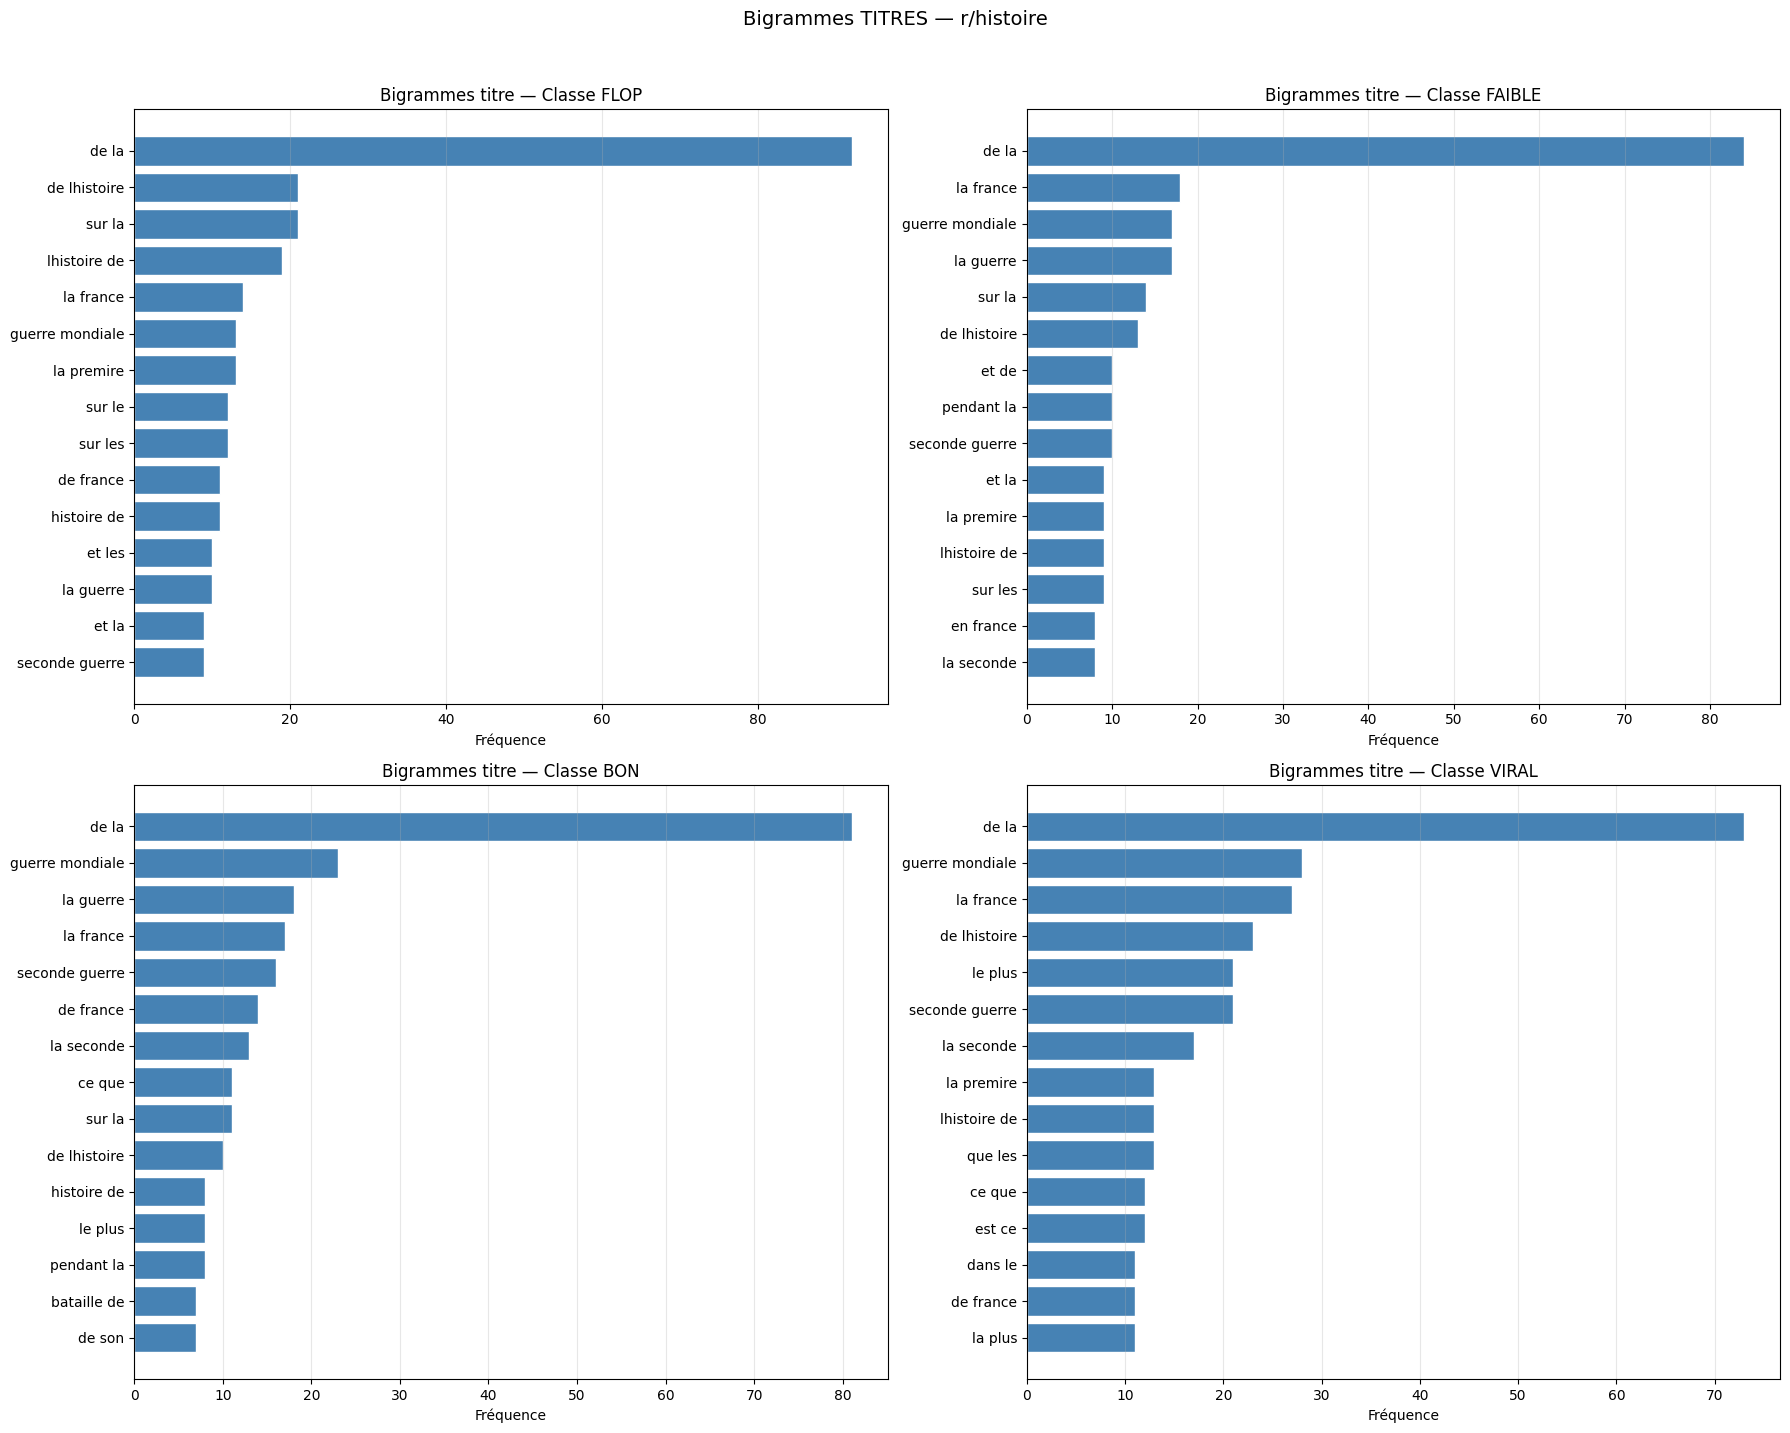

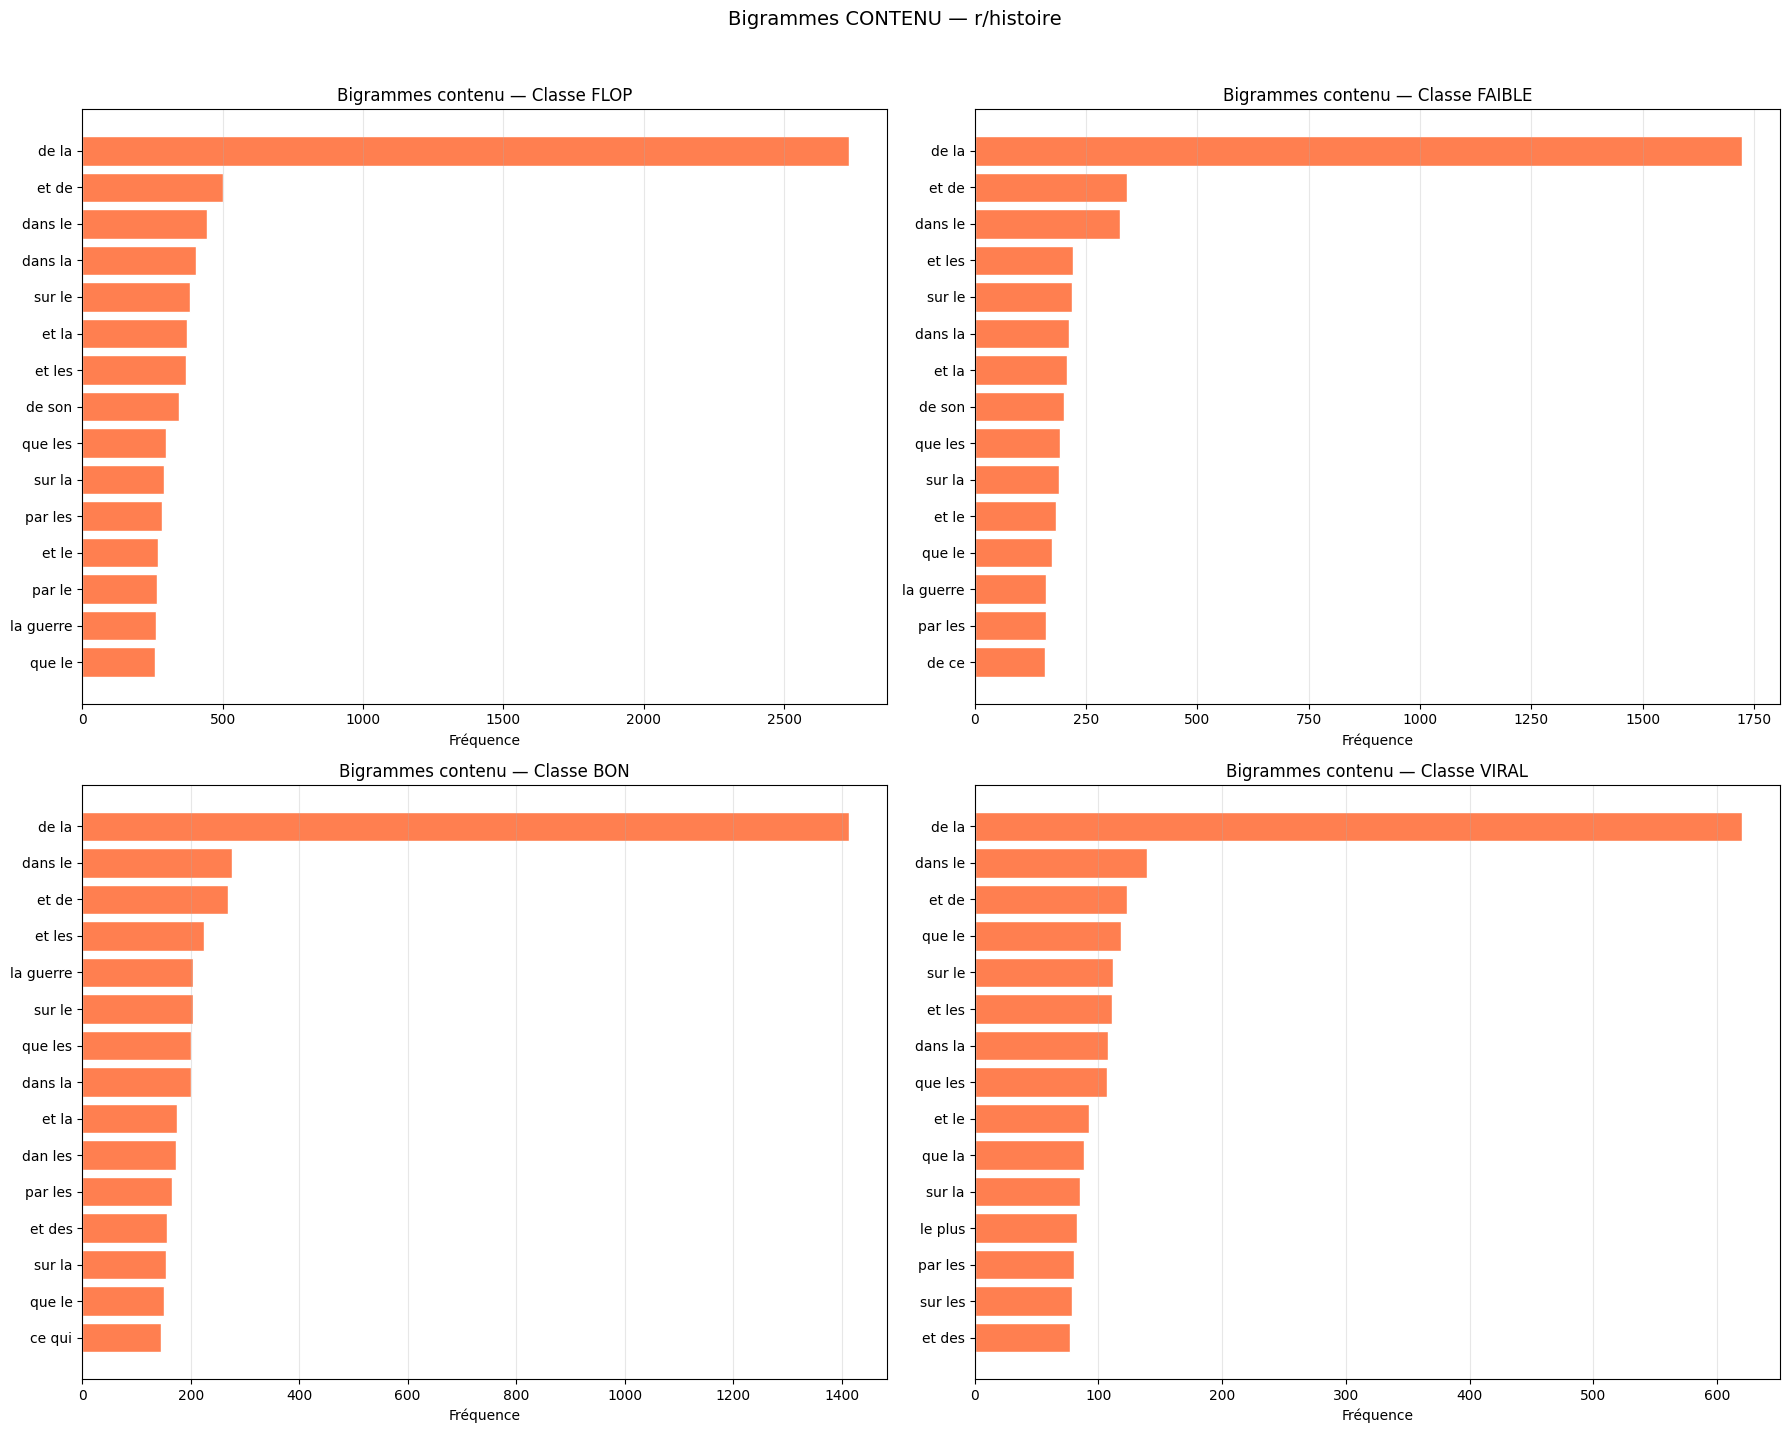

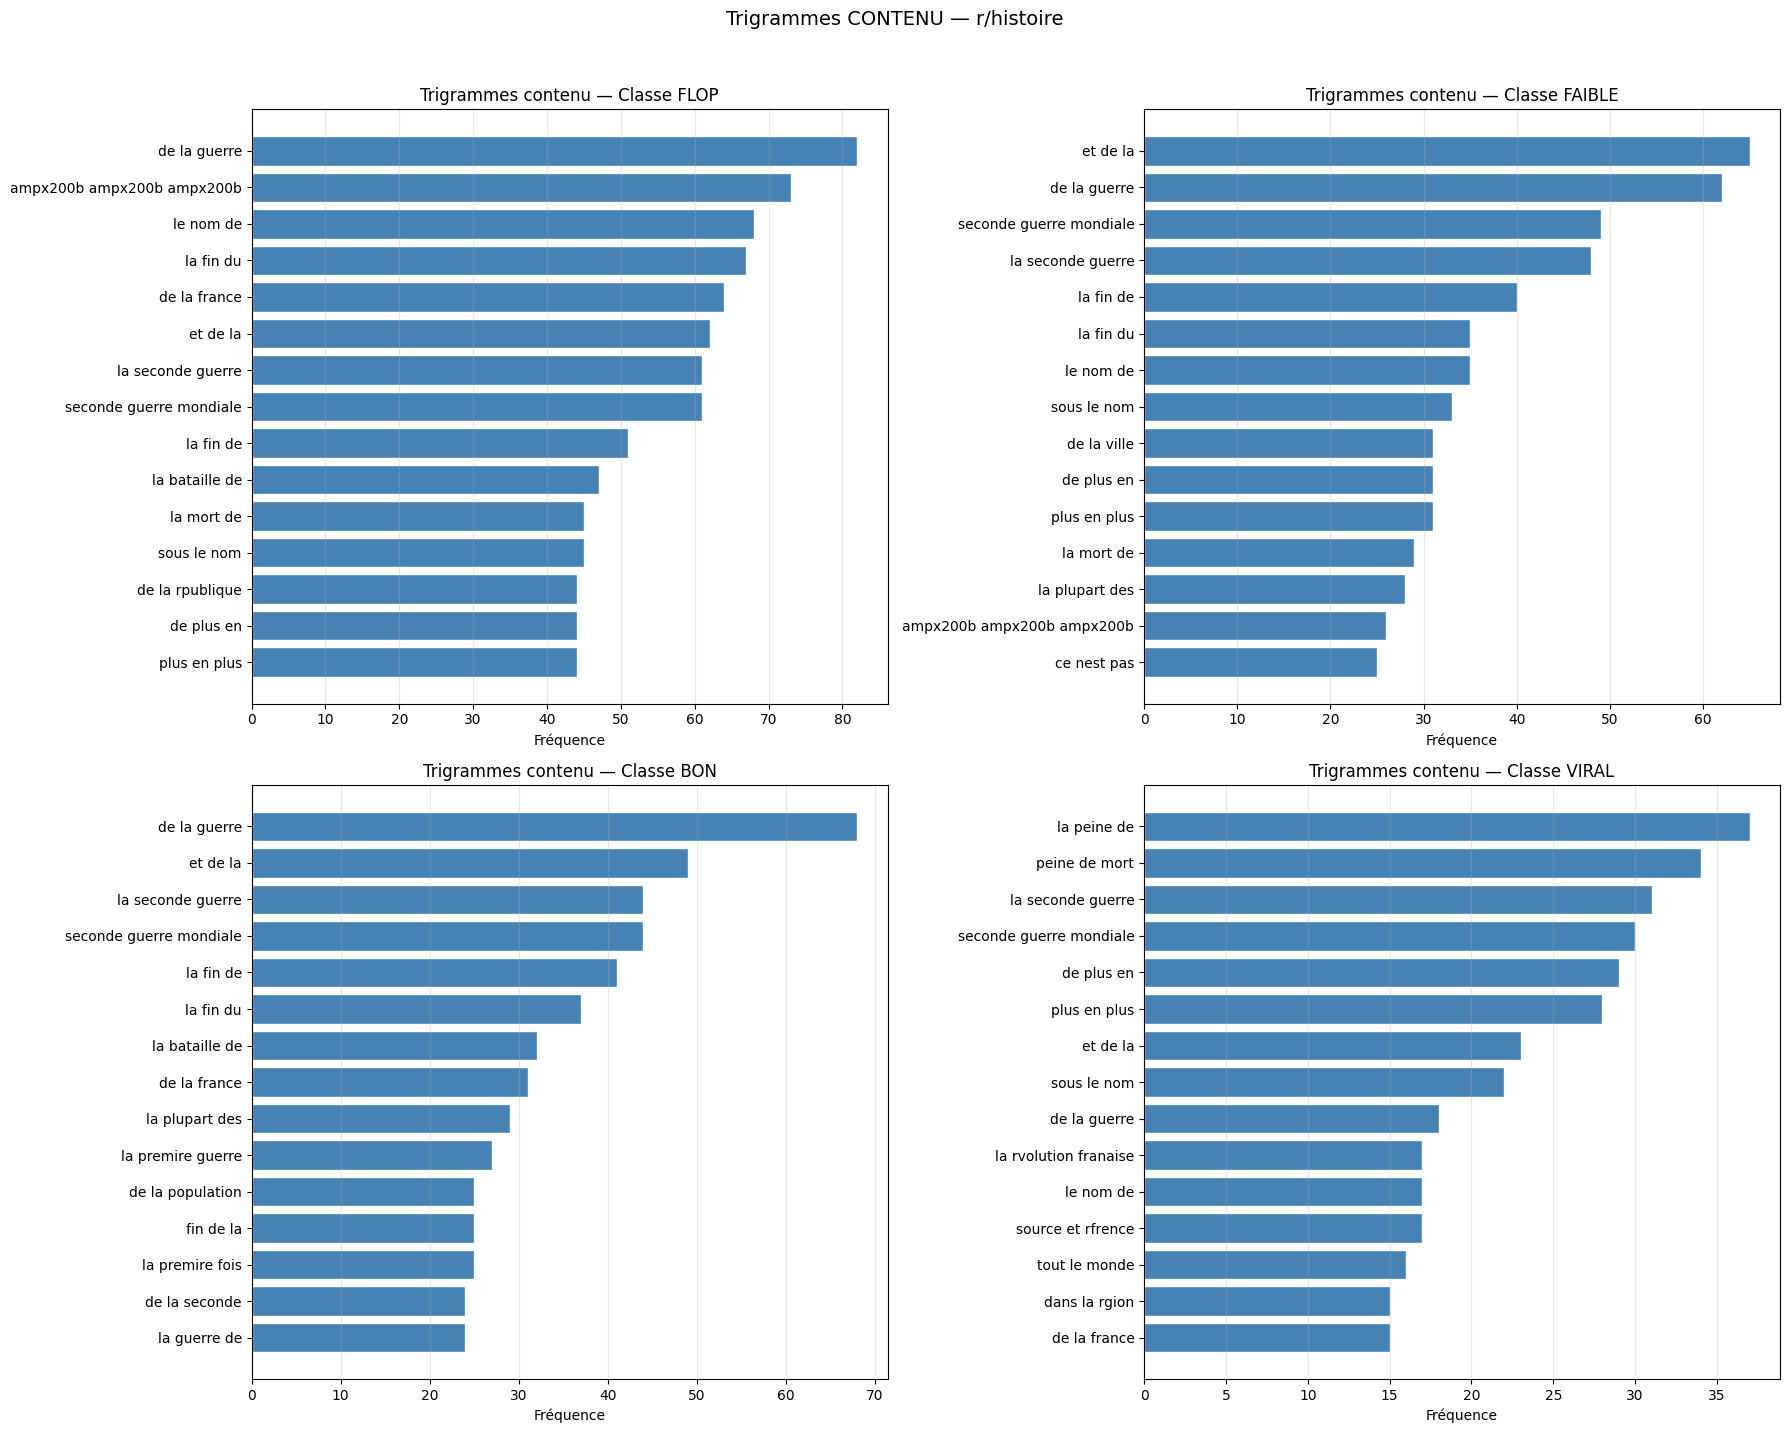

In [ ]:
"""Cellule 13 - Analyse des n-grammes (bigrammes et trigrammes).

Extrait les séquences de mots les plus fréquentes par classe d'engagement, à partir des titres et du contenu.
- Bigrammes des titres par classe.
- Bigrammes du contenu par classe.
- Trigrammes du contenu par classe.
Utilise CountVectorizer de scikit-learn avec un seuil minimal d'apparition de 2.
Sauvegarde les figures sous bigrammes_titres.png, bigrammes_contenu.png et trigrammes_contenu.png.
"""


# CELLULE 13 — N-GRAMMES (TITRE ET CONTENU)
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrammes(textes, n_min, n_max, top_n=15):
    vec = CountVectorizer(ngram_range=(n_min, n_max), max_features=top_n*2, min_df=2)
    try:
        X     = vec.fit_transform(textes)
        vocab = vec.get_feature_names_out()
        freqs = X.sum(axis=0).A1
        top   = sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:top_n]
        return [t[0] for t in top][::-1], [t[1] for t in top][::-1]
    except:
        return [], []

# Bigrammes titres
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    textes = df[df['classe_engagement'] == classe]['titre_final'].fillna('').tolist()
    mots, counts = top_ngrammes(textes, 2, 2)
    if not mots:
        ax.text(0.5, 0.5, 'Pas assez de données', ha='center', va='center')
    else:
        ax.barh(mots, counts, color='steelblue', edgecolor='white')
    ax.set_title(f'Bigrammes titre — Classe {label}', fontsize=12)
    ax.set_xlabel('Fréquence')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Bigrammes TITRES — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bigrammes_titres.png', dpi=150, bbox_inches='tight')
plt.show()

# Bigrammes contenu
df_cont = df[df['longueur_contenu'] > 0]
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    textes = df_cont[df_cont['classe_engagement'] == classe]['contenu_final'].fillna('').tolist()
    mots, counts = top_ngrammes(textes, 2, 2)
    if not mots:
        ax.text(0.5, 0.5, 'Pas assez de données', ha='center', va='center')
    else:
        ax.barh(mots, counts, color='coral', edgecolor='white')
    ax.set_title(f'Bigrammes contenu — Classe {label}', fontsize=12)
    ax.set_xlabel('Fréquence')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Bigrammes CONTENU — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('bigrammes_contenu.png', dpi=150, bbox_inches='tight')
plt.show()

# Trigrammes contenu
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, (classe, label, cmap) in zip(axes.flatten(), classes_info):
    textes = df_cont[df_cont['classe_engagement'] == classe]['contenu_final'].fillna('').tolist()
    mots, counts = top_ngrammes(textes, 3, 3)
    if not mots:
        ax.text(0.5, 0.5, 'Pas assez de données', ha='center', va='center')
    else:
        ax.barh(mots, counts, color='steelblue', edgecolor='white')
    ax.set_title(f'Trigrammes contenu — Classe {label}', fontsize=12)
    ax.set_xlabel('Fréquence')
    ax.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Trigrammes CONTENU — r/{NOM_SUBREDDIT}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('trigrammes_contenu.png', dpi=150, bbox_inches='tight')
plt.show()

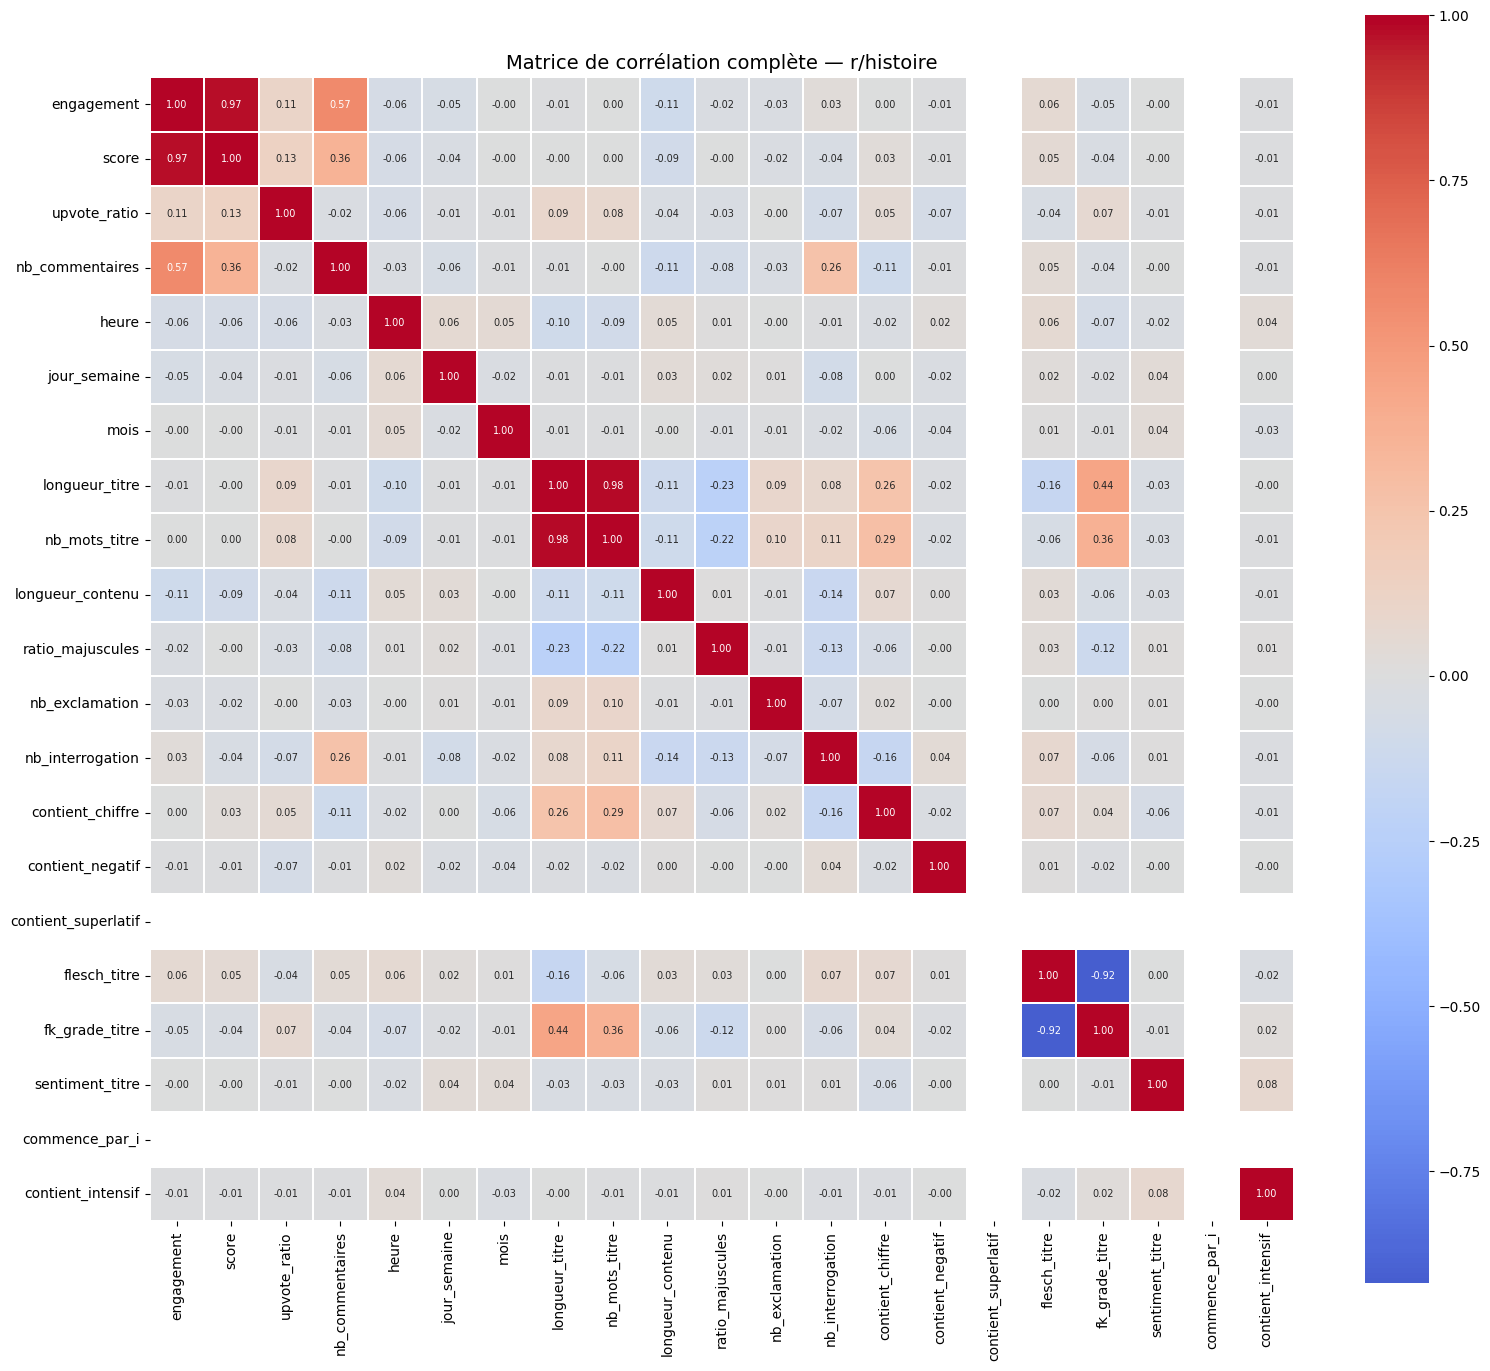


Top corrélations avec l'engagement :
score                  0.9715
nb_commentaires        0.5691
upvote_ratio           0.1121
longueur_contenu      -0.1092
heure                 -0.0604
flesch_titre           0.0585
jour_semaine          -0.0510
fk_grade_titre        -0.0467
nb_interrogation       0.0274
nb_exclamation        -0.0268
ratio_majuscules      -0.0240
contient_negatif      -0.0092
contient_intensif     -0.0070
longueur_titre        -0.0050
sentiment_titre       -0.0048
mois                  -0.0031
nb_mots_titre          0.0007
contient_chiffre       0.0003
contient_superlatif       NaN
commence_par_i            NaN


In [ ]:
"""Cellule 14 - Matrice de corrélation complète.

Calcule et affiche la matrice de corrélation de Pearson entre toutes les features numériques
du dataset (temporelles, textuelles, stylistiques, de lisibilité et de sentiment).
Affiche également le classement des corrélations avec la variable cible engagement.
Sauvegarde la figure sous correlation_complete.png.
"""


# CELLULE 14 — MATRICE DE CORRÉLATION COMPLÈTE
features_corr = [
    'engagement', 'score', 'upvote_ratio', 'nb_commentaires',
    'heure', 'jour_semaine', 'mois',
    'longueur_titre', 'nb_mots_titre', 'longueur_contenu',
    'ratio_majuscules', 'nb_exclamation', 'nb_interrogation',
    'contient_chiffre', 'contient_negatif', 'contient_superlatif',
    'flesch_titre', 'fk_grade_titre', 'sentiment_titre',
    'commence_par_i', 'contient_intensif'
]

corr = df[features_corr].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.3, annot_kws={'size': 7})
plt.title(f'Matrice de corrélation complète — r/{NOM_SUBREDDIT}', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop corrélations avec l\'engagement :')
corr_eng = corr['engagement'].drop('engagement').sort_values(key=abs, ascending=False)
print(corr_eng.round(4).to_string())

In [ ]:
"""Cellule 15 - Sauvegarde du dataset enrichi.

Sélectionne les colonnes pertinentes parmi celles créées tout au long du notebook
et exporte le dataframe enrichi dans un fichier CSV encodé en UTF-8 avec BOM.
Affiche un récapitulatif du nombre de posts, du nombre de features et de la
distribution finale des classes d'engagement.
"""


# CELLULE 15 — SAUVEGARDE DU DATASET ENRICHI
colonnes = [
    'id', 'titre', 'contenu', 'score', 'upvote_ratio', 'nb_commentaires', 'engagement',
    'heure', 'jour_semaine', 'nom_jour', 'mois', 'nom_mois',
    'num_jour_mois', 'semaine_mois', 'tranche_horaire',
    'longueur_titre', 'nb_mots_titre', 'longueur_contenu',
    'contient_question', 'ratio_majuscules', 'nb_exclamation',
    'nb_interrogation', 'nb_points_susp', 'contient_chiffre',
    'est_title_case', 'commence_par_i', 'contient_negatif',
    'contient_superlatif', 'contient_intensif',
    'flesch_titre', 'fk_grade_titre', 'flesch_contenu',
    'sentiment_titre', 'sentiment_contenu_score', 'sentiment_cat',
    'titre_clean', 'contenu_clean', 'titre_final', 'contenu_final',
    'classe_engagement'
]

# Garder uniquement les colonnes qui existent
colonnes_ok = [c for c in colonnes if c in df.columns]

df[colonnes_ok].to_csv(NOM_SORTIE, index=False, encoding='utf-8-sig')

print(f'Dataset enrichi sauvegardé : {NOM_SORTIE}')
print(f'Nombre de posts    : {len(df)}')
print(f'Nombre de features : {len(colonnes_ok)}')
print(f'\nDistribution finale des classes :')
for c in range(4):
    n   = len(df[df['classe_engagement'] == c])
    pct = n / len(df) * 100
    print(f'  {labels_classes[c]:<7} : {n:4d} posts ({pct:.1f}%)')

Dataset enrichi sauvegardé : C:/Users/hakim/histoire_enrichi.csv
Nombre de posts    : 2137
Nombre de features : 40

Distribution finale des classes :
  FLOP    :  620 posts (29.0%)
  FAIBLE  :  478 posts (22.4%)
  BON     :  506 posts (23.7%)
  VIRAL   :  533 posts (24.9%)
